<h1 align="center"><strong><font size="6"> Model Estimation SFM II Dev </h1></strong></font>

<br>
<br>

**SFM II Dev**: development code of various *ablations* **SFM I** with a larger set of factors & enlarged universe of players.


**SFM I** is the model in [Andorra & Göbel (2024)](https://arxiv.org/abs/2412.05911) -- see notebook `013_SFM_Sloan__Submission.ipynb`.



- SFM II DevA: factors = all; HSGPs = None
- SFM II DevB: factors = all / MOM; HSGPs = inter
- SFM II DevC: factors = all / MOM; HSGPs = inter + intra
- SFM II DevD: factors = all / {MOM, MID, FOR}; HSGPs = inter
- SFM II DevE: factors = all / {MOM, MID, FOR}; HSGPs = inter + intra
- SFM II DevF: factors = all; HSGPs = inter
- SFM II DevG: factors = all / Cumulative Player Goals; HSGPs = inter
- SFM II DevH: factors = all / Cumulative Player Goals; HSGPs = None
- SFM II DevI: factors = OG + Positions + MOM; HSGPs = inter + intra
- SFM II DevJ: factors = OG + Positions + MOM + gAppeal; HSGPs = inter + intra
- SFM II DevK: factors = OG + Positions + MOM + gRankConceded_Opponent; HSGPs = inter + intra
- SFM II DevL: factors = OG + Positions + MOM; HSGPs = inter
- SFM II DevM: factors = OG + Positions + MOM + gAppeal; HSGPs = inter
- SFM II DevN: factors = OG + Positions + MOM + gRankConceded_Opponent; HSGPs = inter
- SFM II DevO: factors = OG + Positions + MOM + gRankConceded_Opponent + gShare_Player; HSGPs = inter + intra
- SFM II DevP: factors = OG + Positions + MOM_i + gRankConceded_Opponent; HSGPs = inter
- SFM II DevQ: factors = OG + Positions + MOM + gRankConceded_Opponent + gShare_Player; HSGPs = inter
- SFM II DevR: factors = OG + Positions + MOM_i + gAppeal; HSGPs = inter
- SFM II DevS: factors = OG + Positions + MOM_i + gRankConceded_Opponent; HSGPs = inter + intra
- SFM II DevU: factors = OG + Positions + MOM_i; HSGPs = inter
- SFM II DevV: factors = all; HSGPs = inter + intra
- SFM II DevW: factors = OG + Positions + (MOM_i --> tight priors) + gRankConceded_Opponent; HSGPs = inter + intra
- SFM II DevX: factors = all (MOM_i --> tight priors); HSGPs = inter + intra
<br>



> **REVISION IN PROGRESS (2026-08-04)** -- mechanical repairs from `REFEREE_REPORT.md` applied:
> **M2.1** new-player baseline rescaled (`baseline_sigma` restored) | **M2.2** pooled `beta__player`
> reused from the posterior instead of redrawn from the prior | **M3.1** predictive probabilities are
> the posterior **mean**, not median | **M3.2** ECE last-bin fix | **M3.3** naive benchmark is now the
> marginal-frequency forecast | **M7** prior-predictive check enabled, sampler seeded,
> `target_accept` 0.99 -> 0.9, convergence-diagnostics cell added, duplicate in-sample PPC removed,
> reduced parameter posterior saved to netCDF | **eta parity test** added before Export (guards the
> M2 bug class) | minor: factor-wise zero-variance rule in CS-scaling, `data_oos` explicit copy,
> dead cells removed.
>
> **Not yet done (harness / decisions):** M1 momentum treatment, M4 expanding-window harness +
> sealed holdout + re-selection, M5 SAR estimand, M6 period term, M8 unification.
> **Smoke-test on Colab with the numpyro sampler before any full run: set `SMOKE = True` in the USER INTERACTION cell (default) and run top to bottom; then `SMOKE = False`** (SFMMO lesson: the backend
> the notebook actually uses is the one that must pass). Pre-revision snapshot:
> `XX__vintage/SFM_II__dev__v260804.ipynb`.


In [1]:
# --- Connect to Google-Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# -------------------------------------- USER INTERACTION -------------------------------------- #

# --- SMOKE mode: 200/200 draws for a fast end-to-end test of ALL cells on the numpyro
#     backend (the backend is what must pass -- SFMMO lesson). FIRST RUN AFTER THE
#     2026-08-04 REVISION MUST BE SMOKE; then set False for the real fit.
SMOKE = True

# --- Sampler acceptance target. Contingency ladder if the diagnostics cell reports
# --- divergences at FULL draws: 0.9 -> 0.95 -> 0.99 / non-center the player ZSN.
TARGET_ACCEPT = 0.9

# --- Set the directory to the datafile ('SFM_data_byPlayer.csv'):
directory = '/content/drive/MyDrive/Colab Notebooks/51_SoccerAnalytics/'

# --- Which is the last season you want to Include in Training? [YYYY/YY]
train_end = '2023/24'

# --- Cross-Sectional Standardization, or whole-sample Standardization?
do__scaleCS = True

# --- With HSGPs or without?
devVersion = 'M' # ---> A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,R,Q,S,U,V,W,X,OG

# -------------------------------------- USER INTERACTION -------------------------------------- #

In [3]:
!pip install -qq pymc numpyro
!pip install -qq plotly
!pip install -qq graphviz
!pip install -qq arviz arviz-plots
!pip install -qq jax[cuda] -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

In [4]:
from typing import List, Union

#import arviz as az
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
import arviz as az
import arviz_plots as azp
import xarray as xr
from matplotlib.lines import Line2D
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler

# --- Interactive Plots:
import plotly.graph_objects as go
import plotly



seed = sum(map(ord, "sfm"))
rng = np.random.default_rng(seed)

pm.__version__

'5.28.4'

In [5]:
np.__version__

'2.0.2'

<br>

## 00 &emsp; Auxiliaries

In [6]:
def compute_log_likelihood(predictions, actuals):
    """
    predictions: array of shape (n_samples, n_categories)
                 e.g., [[0.4, 0.35, 0.2, 0.05], ...] for one match
    actuals: array of actual outcomes [0, 1, 2, 3, ...]
    """
    log_lik = 0
    for i, actual in enumerate(actuals):
        # Get probability assigned to actual outcome
        prob_actual = predictions[i][actual]
        log_lik += np.log(prob_actual + 1e-10)  # Add small epsilon to avoid log(0)

    return log_lik



def multi_class_brier_score(predictions, actuals, n_classes=4):
    """
    predictions: (n_samples, n_classes) probability matrix
    actuals: (n_samples,) actual outcomes
    """
    # Convert actuals to one-hot encoding
    one_hot = np.zeros((len(actuals), n_classes))
    one_hot[np.arange(len(actuals)), actuals] = 1

    # Compute Brier score
    brier = np.mean(np.sum((predictions - one_hot)**2, axis=1))
    return brier


def ranked_probability_score(predictions, actuals, n_classes=4):
    """
    Ranked Probability Score for ordinal outcomes
    """
    rps = 0
    for i, actual in enumerate(actuals):
        # Cumulative probabilities
        pred_cumsum = np.cumsum(predictions[i])

        # Actual cumulative (one-hot converted to cumulative)
        actual_cumsum = np.zeros(n_classes)
        actual_cumsum[actual:] = 1

        # RPS for this prediction
        rps += np.sum((pred_cumsum - actual_cumsum)**2)

    return rps / len(actuals)



def expected_calibration_error(predictions, actuals, n_bins=10):
    """
    ECE for probabilistic predictions.
    Bins by confidence (max predicted probability) and compares to accuracy.
    """
    # Get confidence (max predicted probability) and predicted class
    confidence = np.max(predictions, axis=1)
    pred_classes = np.argmax(predictions, axis=1)

    # Create bins
    bin_edges = np.linspace(0, 1, n_bins + 1)

    ece = 0
    for i in range(n_bins):
        # Find predictions in this confidence bin
        # --- M3.2 FIX (referee report): include confidence == 1.0 in the last bin; the old
        #     half-open binning dropped perfect-confidence predictions from EVERY bin
        #     (the degenerate naive scored ECE = 0.000 instead of its true 0.174).
        if i < n_bins - 1:
            in_bin = (confidence >= bin_edges[i]) & (confidence < bin_edges[i+1])
        else:
            in_bin = (confidence >= bin_edges[i]) & (confidence <= bin_edges[i+1])

        if np.sum(in_bin) > 0:
            # Average confidence in bin
            avg_conf = np.mean(confidence[in_bin])

            # Actual accuracy in bin
            avg_acc = np.mean(pred_classes[in_bin] == actuals[in_bin])

            # Weighted by bin size
            ece += np.abs(avg_conf - avg_acc) * np.sum(in_bin)

    return ece / len(actuals)


def ordinal_accuracy(predictions, actuals):
    """
    Percentage of times the highest probability category was correct
    """
    pred_classes = np.argmax(predictions, axis=1)
    return np.mean(pred_classes == actuals)


def ordinal_mae(predictions, actuals):
    """
    MAE treating categories as ordinal
    """
    pred_classes = np.argmax(predictions, axis=1)
    return np.mean(np.abs(pred_classes - actuals))


def expected_goals(predictions):
    """
    Expected number of goals from probability distribution
    """
    goal_values = np.array([0, 1, 2, 3])  # Treating 3+ as exactly 3
    return np.dot(predictions, goal_values)

def xGoals_mae(predictions, actuals):
    """
    MAE of expected values
    """
    expected = expected_goals(predictions)
    return np.mean(np.abs(expected - actuals))


## 00 &emsp; Data preparation

In [7]:
# ======================================== Load the Data ======================================== #


#complete_data = pd.read_csv(f"{directory}/10_data/106_Website/data_byPlayer.csv")
complete_data = pd.read_csv(f"{directory}/10_data/106_Website/data_byPlayer__SFM_II.csv")

# --- Pre-Processing, Part I:
complete_data['kick_off'] = pd.to_datetime(complete_data['kick_off'])
complete_data = complete_data.sort_values(['name_player','season','kick_off'])
complete_data

,goal,goals_in_match,goals_in_first_half,goals_in_second_half,goals_scored_avg_minutes_left,points_team,points_opp,goalsscored_inGame_team,goalsscored_inGame_opp,goalsscored_cum_team,...,goalsscored_rank_opp,goalsconceded_rank_team,goalsscored_diff,goal_balance_team,goal_balance_opp,goal_balance_diff,points_diff,goalsscored_share_player_team,name_player,position_player
0,0.0,0.0,0.0,0.0,0.0,4.0,7.0,0.0,4.0,4.0,...,0.0,7.5,-6.0,1.0,7.0,-6.0,-3.0,0.000000,aaron-connolly,Sturm
1,0.0,0.0,0.0,0.0,0.0,4.0,4.0,1.0,1.0,4.0,...,10.0,15.5,-1.0,-3.0,-1.0,-2.0,0.0,0.000000,aaron-connolly,Sturm
2,0.0,0.0,0.0,0.0,0.0,5.0,4.0,0.0,0.0,5.0,...,17.0,14.0,1.0,-3.0,-4.0,1.0,1.0,0.000000,aaron-connolly,Sturm
3,0.0,0.0,0.0,0.0,0.0,6.0,8.0,0.0,2.0,5.0,...,2.5,10.0,-7.0,-3.0,-1.0,-2.0,-2.0,0.000000,aaron-connolly,Sturm
4,1.0,2.0,1.0,1.0,19.0,6.0,11.0,3.0,0.0,5.0,...,2.5,10.0,-9.0,-5.0,5.0,-10.0,-5.0,0.000000,aaron-connolly,Sturm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374914,0.0,0.0,0.0,0.0,0.0,43.0,28.0,2.0,0.0,56.0,...,15.0,15.5,28.0,5.0,-19.0,24.0,15.0,0.160714,zvjezdan-misimovic,Mittelfeld
374915,0.0,0.0,0.0,0.0,0.0,46.0,51.0,2.0,4.0,58.0,...,0.0,15.0,-5.0,7.0,26.0,-19.0,-5.0,0.155172,zvjezdan-misimovic,Mittelfeld
374916,0.0,0.0,0.0,0.0,0.0,46.0,56.0,1.0,1.0,60.0,...,5.0,15.5,8.0,4.0,14.0,-10.0,-10.0,0.150000,zvjezdan-misimovic,Mittelfeld
374917,1.0,1.0,1.0,0.0,24.0,47.0,46.0,3.0,1.0,61.0,...,8.0,13.0,15.0,4.0,-5.0,9.0,1.0,0.147541,zvjezdan-misimovic,Mittelfeld


In [8]:
print(f'Total Number of Players: {len(complete_data['name_player'].unique())}')


Total Number of Players: 2908


In [9]:
# ======================================== Feature Engineering ======================================== #

# --- Goal Appeal (of the match):
complete_data['goal_appeal'] = complete_data['goalsconceded_rank_opp'] - complete_data['goalsscored_rank_team']


# ------------------------ Player Momentum: exponentially-weighted MA of previous goals ------------------------ #

# --- Calculate the Number of Goals scored in the PREVIOUS appearance -- and fill initial NAs with the cumulative number of goals:
complete_data['FD__goalsscored_cum_player'] = complete_data.groupby(['season','name_player'])['goalsscored_cum_player'].diff().fillna(complete_data['goalsscored_cum_player'])

# --- Calculate MOMENTUM: EWMA of goals scored in previous games (halflife == one appearance)
playerMomentum = pd.DataFrame(complete_data.groupby(['season','name_player'])['FD__goalsscored_cum_player'].ewm(halflife=1).mean().reset_index()).set_index('level_2')


# --- Merge:
complete_data['goalsscored_MOM_player'] = playerMomentum['FD__goalsscored_cum_player']


In [10]:
# ======================================== Pre-Processing: Part II ======================================== #

# --- Fill missing positions WITHIN each (season, player) group.
# --- M5-ADDENDUM FIX (referee report): the old chained groupby-bfill().ffill() ran the
#     second fill GLOBALLY -- all 37,361 all-NaN groups (10.0% of rows, goals/app 0.022,
#     i.e. goalkeeper-like) inherited the alphabetically-previous player's position
#     (20,386 'Mittelfeld', 16,963 'Sturm'). The grouped transform restores the intended
#     behaviour: NaN stays NaN and the np.where dummies code it as the reference class.
complete_data['position_player'] = complete_data.groupby(['season','name_player'])['position_player'].transform(lambda s: s.bfill().ffill())

# --- Create Dummies for positions:
# --- COLLINEARITY FIX (2026-08-10 vintage): the universe is scorer-oriented -- 'Abwehr' is
# --- only ~0.12% of rows, and the unlabelled goalkeeper-like group (the de facto reference
# --- class, ~10% in earlier vintages) is gone now that positions are fully populated. With
# --- both MID and FOR, corr(MID, FOR) = -0.9975 and the pair partitions 99.88% of the data:
# --- collinear with the intercept, so only beta_FOR - beta_MID is identified. ONE dummy
# --- spans the same space -> keep position_FOR, reference = midfield (+ the few defenders).
complete_data['position_FOR'] = np.where(complete_data['position_player'] == 'Sturm',1,0)


In [11]:
#complete_data.loc[complete_data['position_player'].isna(),['name_player','season','gameday','position_player']]

In [12]:
complete_data.shape

(374919, 41)

In [13]:
#for m in [2,3,4,8]:
#  playerMomentum = pd.DataFrame(complete_data.groupby(['season','name_player'])['FD__goalsscored_cum_player'].ewm(halflife=m).mean().reset_index()).set_index('level_2')
#  complete_data[f'goalsscored_MOM{m}_player'] = playerMomentum['FD__goalsscored_cum_player']

#features = ["points_diff",'goalsscored_cum_player','goalsconceded_rank_opp','goalsscored_share_player_team','goal_appeal'] + complete_data.filter(like='goalsscored_MOM',axis=1).columns.tolist()
#complete_data[features].corr()

In [14]:
# ======================================== Pre-Processing: Part III ======================================== #

print(f'Number of Observations \'goalsscored_share_player_team\' > 1: {sum(complete_data['goalsscored_share_player_team'] > 1)} ')

complete_data = complete_data.loc[complete_data['goalsscored_share_player_team'] <= 1,:].reset_index(drop=True)

Number of Observations 'goalsscored_share_player_team' > 1: 12 


In [15]:
# ======================================== Define the Factors ======================================== #


if devVersion in ['A','F','V','X']:

  # --- Numerical Factors:
  factors_CS = ["points_diff",'goalsscored_cum_player','goalsconceded_rank_opp',
                'goalsscored_share_player_team','goal_appeal']
  # --- Other Factors:
  other_factors = ["home_pitch",'position_FOR','goalsscored_MOM_player']

elif devVersion in ['B','C']:

  # --- Numerical Factors:
  factors_CS = ["points_diff",'goalsscored_cum_player','goalsconceded_rank_opp',
                'goalsscored_share_player_team','goal_appeal']
  # --- Other Factors:
  other_factors = ["home_pitch",'position_FOR']

elif devVersion in ['D','E']:

  # --- Numerical Factors:
  factors_CS = ["points_diff",'goalsscored_cum_player','goalsconceded_rank_opp',
                'goalsscored_share_player_team','goal_appeal']
  # --- Other Factors:
  other_factors = ["home_pitch"]

elif devVersion in ['G','H']:

  # --- Numerical Factors:
  factors_CS = ["points_diff",'goalsconceded_rank_opp',
                'goalsscored_share_player_team','goal_appeal']
  # --- Other Factors:
  other_factors = ["home_pitch",'position_FOR','goalsscored_MOM_player']

elif devVersion in ['I','L']:

  # --- Numerical Factors:
  factors_CS = ["points_diff"]
  # --- Other Factors:
  other_factors = ["home_pitch",'position_FOR','goalsscored_MOM_player']

elif devVersion in ['J','M','R']:

  # --- Numerical Factors:
  factors_CS = ["points_diff",'goal_appeal']
  # --- Other Factors:
  other_factors = ["home_pitch",'position_FOR','goalsscored_MOM_player']

elif devVersion in ['K','N','P','S','W']:

  # --- Numerical Factors:
  factors_CS = ["points_diff",'goalsconceded_rank_opp']
  # --- Other Factors:
  other_factors = ["home_pitch",'position_FOR','goalsscored_MOM_player']

elif devVersion in ['O','Q']:

  # --- Numerical Factors:
  factors_CS = ["points_diff",'goalsconceded_rank_opp','goalsscored_share_player_team']
  # --- Other Factors:
  other_factors = ["home_pitch",'position_FOR','goalsscored_MOM_player']


elif devVersion in ['U']:

  # --- Numerical Factors:
  factors_CS = ["points_diff"]
  # --- Other Factors:
  other_factors = ["home_pitch",'position_FOR','goalsscored_MOM_player']


elif devVersion == 'OG':

  # --- Numerical Factors:
  factors_CS = ["points_diff"]
  # --- Other Factors:
  other_factors = ["home_pitch"]


# --- Concatenate:
factors = other_factors + factors_CS
factors_team = [f for f in (other_factors + factors_CS) if f != 'goalsscored_MOM_player']

if devVersion in ['A','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','U','V','W','X']:
  factors_player = ['goalsscored_MOM_player']
else:
  factors_player = []


In [16]:
# ======================================== Some Data Preprocessing ======================================== #


# --- 0.3 Some Type-Setting:
complete_data["goal"] = complete_data["goal"].astype(int)
complete_data["goals_in_match"] = complete_data["goals_in_match"].astype(int)

complete_data["kick_off"] = pd.to_datetime(
    complete_data["kick_off"], yearfirst=True
).dt.normalize()


# --- 0.4 Player-Maturity: compute season number for each player
complete_data["season_nbr"] = complete_data.groupby(["name_player"])[
    "season"
].transform(lambda x: x.factorize(sort=True)[0])




# --- 0.5 Final Sorting for Convenience:
complete_data = complete_data.sort_values(["name_player", "kick_off"]).reset_index(
    drop=True
)



# --- 0.6
data_oos = complete_data[complete_data.season == '2024/25'].copy()

# --- 0.7 Get the Training-Data only:
complete_data = complete_data[complete_data.season <= train_end]


complete_data

,goal,goals_in_match,goals_in_first_half,goals_in_second_half,goals_scored_avg_minutes_left,points_team,points_opp,goalsscored_inGame_team,goalsscored_inGame_opp,goalsscored_cum_team,...,points_diff,goalsscored_share_player_team,name_player,position_player,goal_appeal,FD__goalsscored_cum_player,goalsscored_MOM_player,position_MID,position_FOR,season_nbr
0,0,0,0.0,0.0,0.0,4.0,7.0,0.0,4.0,4.0,...,-3.0,0.000000,aaron-connolly,Sturm,-1.0,0.0,0.000000,0,1,0
1,0,0,0.0,0.0,0.0,4.0,4.0,1.0,1.0,4.0,...,0.0,0.000000,aaron-connolly,Sturm,-2.0,0.0,0.000000,0,1,0
2,0,0,0.0,0.0,0.0,5.0,4.0,0.0,0.0,5.0,...,1.0,0.000000,aaron-connolly,Sturm,0.5,0.0,0.000000,0,1,0
3,0,0,0.0,0.0,0.0,6.0,8.0,0.0,2.0,5.0,...,-2.0,0.000000,aaron-connolly,Sturm,2.5,0.0,0.000000,0,1,0
4,1,2,1.0,1.0,19.0,6.0,11.0,3.0,0.0,5.0,...,-5.0,0.000000,aaron-connolly,Sturm,-9.0,0.0,0.000000,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374902,0,0,0.0,0.0,0.0,43.0,28.0,2.0,0.0,56.0,...,15.0,0.160714,zvjezdan-misimovic,Mittelfeld,9.0,1.0,0.593774,1,0,6
374903,0,0,0.0,0.0,0.0,46.0,51.0,2.0,4.0,58.0,...,-5.0,0.155172,zvjezdan-misimovic,Mittelfeld,4.5,0.0,0.296887,1,0,6
374904,0,0,0.0,0.0,0.0,46.0,56.0,1.0,1.0,60.0,...,-10.0,0.150000,zvjezdan-misimovic,Mittelfeld,1.5,0.0,0.148443,1,0,6
374905,1,1,1.0,0.0,24.0,47.0,46.0,3.0,1.0,61.0,...,1.0,0.147541,zvjezdan-misimovic,Mittelfeld,8.0,0.0,0.074222,1,0,6


In [17]:
complete_data[factors_CS + ['goalsscored_MOM_player']].corr()

,points_diff,goal_appeal,goalsscored_MOM_player
points_diff,1.000000,0.722746,0.085812
goal_appeal,0.722746,1.000000,0.120894
goalsscored_MOM_player,0.085812,0.120894,1.000000


In [18]:
# ======================================== Number of Players ======================================== #


players_ordered = complete_data["name_player"].sort_values().unique()
players_ordered.shape

(2850,)

In [19]:
# ======================================== Just some Checking ======================================== #

assert complete_data["name_player"].sort_values().unique().shape[0] == len(
    players_ordered
)

## 00 &emsp; Some Data-Inspection

In [20]:
# ======================================== Share of Goals ======================================== #


complete_data["goals_in_match"].value_counts(normalize=True).round(4)

,proportion
goals_in_match,
0,0.8261
1,0.1506
2,0.0204
3,0.0026
4,0.0003
5,0.0000


In [21]:
# ======================================== Frequency of Goals ======================================== #

complete_data["goals_in_match"].value_counts()

,count
goals_in_match,
0,294436
1,53670
2,7287
3,923
4,90
5,10


## 1 &emsp; Feature Engineering

In [22]:
# ======================================== Winsorization of Goals >= 3 ======================================== #

complete_data["goals_cats"] = np.where(
    complete_data["goals_in_match"] >= 3, 3, complete_data["goals_in_match"]
)


In [23]:
complete_data[factors_CS]

,points_diff,goal_appeal
0,-3.0,-1.0
1,0.0,-2.0
2,1.0,0.5
3,-2.0,2.5
4,-5.0,-9.0
...,...,...
374902,15.0,9.0
374903,-5.0,4.5
374904,-10.0,1.5
374905,1.0,8.0


In [24]:
# ======================================== Cross-Sectional Standardization (by Gameday) ======================================== #

# --- Some Game-Day-Adjustments are necessary
complete_data['gameday_orig'] = complete_data['gameday'].copy()
complete_data['gameday'] = [int(float(i.split('_')[1][2:])) for i in complete_data['id_match'].values]

# --- Cross-Sectional Scaling:
if do__scaleCS:
  # --- minor FIX (referee report): scale factor-wise -- the old rule zeroed ALL factors
  #     in a gameday bucket if ANY single factor had zero std there.
  def _cs_scale(x):
      return x.apply(lambda col: (col - col.mean()) / col.std() if (len(x) > 1 and col.std() > 0) else col * 0.0)

  data__scaleCS = complete_data.groupby('gameday')[factors_CS].apply(_cs_scale).reset_index().set_index('level_1').drop('gameday',axis=1)


  # --- Merge:
  complete_data[factors_CS] = data__scaleCS


In [25]:
complete_data[factors_CS]

,points_diff,goal_appeal
0,-0.942005,-0.311176
1,-0.071268,-0.466521
2,0.143735,-0.132818
3,-0.461552,0.119277
4,-0.970363,-1.394859
...,...,...
374902,0.708973,0.924349
374903,-0.362781,0.353211
374904,-0.587908,-0.033041
374905,-0.049620,0.790554


In [26]:
# ======================================== 1.1 Factor Standardization ======================================== #

if not do__scaleCS:
    factors_CS_train = complete_data[factors_CS].copy()

    # --- Do the Standardization
    scaler = StandardScaler()
    factors_CS_sdz = pd.DataFrame(
        scaler.fit_transform(factors_CS_train), columns=factors_CS
    )

    # --- Add the non-numeric factor to the standardized DataFrame
    factors_sdz = factors_CS_sdz.copy()
    factors_sdz[other_factors] = complete_data[other_factors].copy()

    # --- Ensure that the order is the same as the PyMC coords later on
    factors_sdz = factors_sdz[factors]


    print('\nScaling data across the Whole Sample!\n')


else:

    # --- Standardization already done! Ensure that the order is the same as the PyMC coords later on:
    factors_sdz = complete_data[factors].copy()

    print('\nData already scaled cross-sectionally!\n')




Data already scaled cross-sectionally!



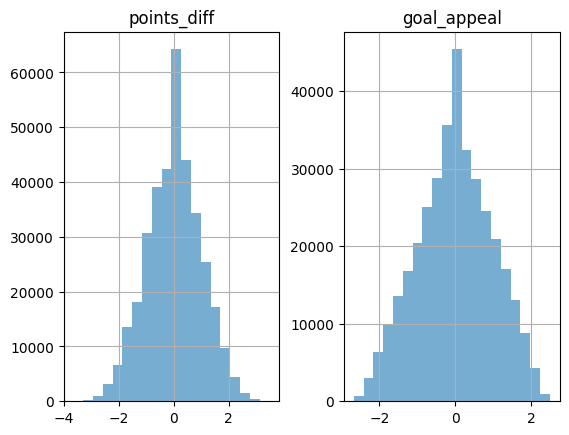

In [27]:
factors_sdz[factors_CS].hist(alpha=0.6, bins=20);

## 2 &emsp; HSGP Parameters

**Maturity & calendar structure — what is actually fitted (updated 2026-08-04, referee report M6).**

Two **global** curves shared by all players (not per-player trajectories):

- `f_long(season_nbr)`: a population-average **career-age curve** over each player's season index
  *within the data window*. Caveat (M6): `season_nbr` is left-truncated — everyone present in
  2000/01, and every mid-career arrival into the big-5 leagues, enters at 0 — so the curve mixes
  career age with data-entry cohort.
- `f_within(gameday)`: a population-average **within-season calendar effect** (inter+intra
  variants only). Bundesliga ends at gameday 34, so the 35–38 tail is estimated from the other
  four leagues.

There is **no calendar-period term**: per-appearance scoring fell ~18% over 2000/01→2022/23
(verified), and without an era effect that drift loads onto the player effects and the career
curve (the age–period–cohort confound). The `F_ERA` variant in `SFM_II__dev_EW.ipynb` tests the
remedy (a shared HSGP over calendar season); adopt it here only if it survives the pre-registered
paired test.

All of these use the [Hilbert-Space decomposition](https://arxiv.org/abs/2004.11408) of the GP
(HSGP), [available in PyMC](https://www.pymc.io/projects/docs/en/stable/api/gp/generated/pymc.gp.HSGP.html).

### 2.1 &emsp; Choosing the approximation parameters

HSGP is mainly defined by two parameters, `m` and `c`, respectively the number of basis vectors and the multiplier determining the boundary of the approximation (see [this](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/HSGP-Basic.html) for more details). PyMC actually has a helper function to help us choose `m` and `c`:

In [28]:
# ==================================== Intra-Season Fluctuations ==================================== #
m_within, c_within = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[0, complete_data.gameday.max()],
    lengthscale_range=[5, 25],
    cov_func="matern52",
)

print("Recommended smallest number of basis vectors (m) --- Intra-Season:", m_within)
print("Recommended smallest scaling factor (c) --- Intra-Season:",          np.round(c_within, 1))


# ==================================== Inter-Season Fluctuations ==================================== #
m_long, c_long = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[0, 30], #complete_data.season_nbr.max()],
    lengthscale_range=[2, 6],
    cov_func="matern52",
)

print("Recommended smallest number of basis vectors (m) --- Inter-Season:", m_long)
print("Recommended smallest scaling factor (c) --- Inter-Season:",          np.round(c_long, 1))

Recommended smallest number of basis vectors (m) --- Intra-Season: 54
Recommended smallest scaling factor (c) --- Intra-Season: 5.4
Recommended smallest number of basis vectors (m) --- Inter-Season: 32
Recommended smallest scaling factor (c) --- Inter-Season: 1.6


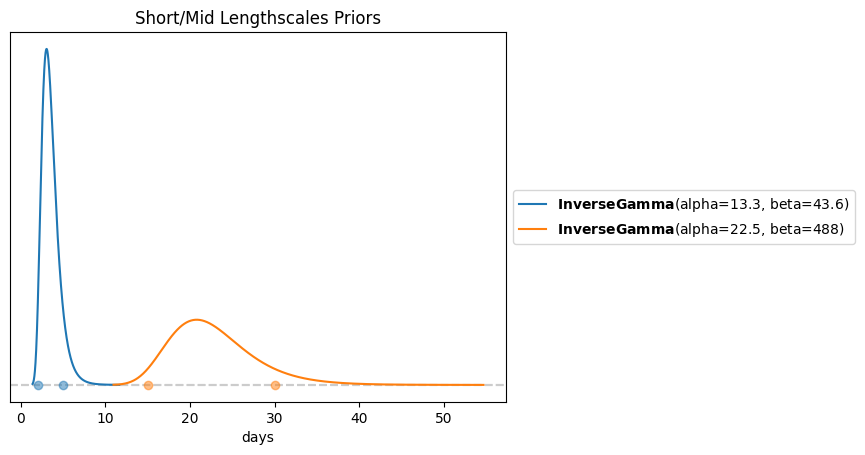

In [29]:
# ==================== Lengthscale Priors (preliz-free; SFMMO lesson) ==================== #
# --- InverseGamma(alpha, beta) constants precomputed OFFLINE (2026-08-04) with the sfmII
# --- venv's preliz 0.23.0: pz.maxent(pz.InverseGamma(), lower, upper) -- bit-identical to
# --- what this notebook always used. preliz is NOT installed or imported on Colab: it
# --- crashes the pymc/numpyro stack there (known problem from the SFMMO).

from types import SimpleNamespace

ls_short_dist  = SimpleNamespace(lower=2,  upper=5,  alpha=13.29478010, beta=43.62832634)   # days
ls_medium_dist = SimpleNamespace(lower=15, upper=30, alpha=22.45420627, beta=487.52137343)  # days
ls_long_dist   = SimpleNamespace(lower=2,  upper=6,  alpha=9.54036477,  beta=34.71244771)   # seasons


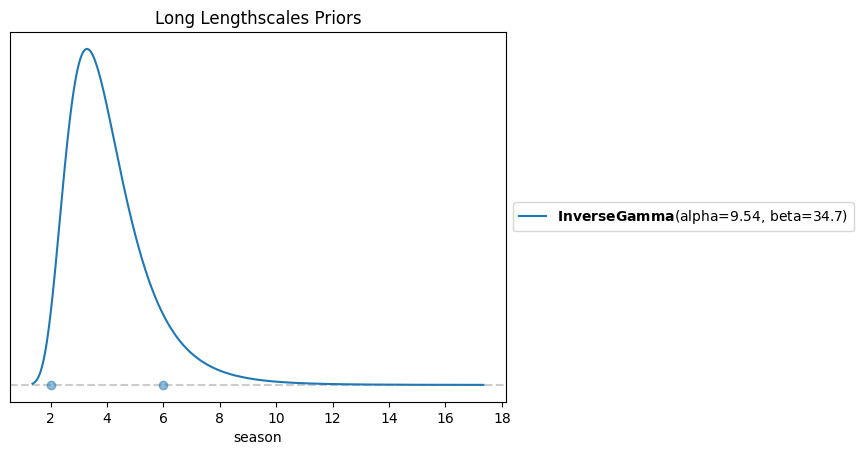

In [30]:
# --- (lengthscale priors defined above -- preliz removed from the Colab runtime)


We can now implement our PyMC model. It'll be a big one, but we'll take it step by step.

## 3 &emsp; PyMC Model

### 3.1 &emsp; Variable Definition to set the PyMC Model

In [31]:
# =========================== Static Variables for Train- & Test-Set =========================== #

#unique_gamedays = complete_data["gameday"].sort_values().unique()
#unique_seasons = complete_data["season_nbr"].sort_values().unique()

unique_gamedays = np.arange(1,39)
unique_seasons = np.arange(0,31)


In [32]:
# =========================== Changing Variables for Train- & Test-Set =========================== #

# --- Index for Players:
player_idx = pd.Categorical(
    complete_data["name_player"], categories=players_ordered
).codes

# --- Index for Game Days:
gameday_idx = pd.Categorical(
    complete_data["gameday"],
    categories=unique_gamedays,
).codes


# --- Types of HSGP timescales:
if devVersion in ['B','D','F','G','L','M','N','P','Q','R','U']:
  timescale = ['long']
else:
  timescale = ['short', 'medium', 'long']

# --- Set the Coords:
COORDS = {
    "event": complete_data["goals_cats"].factorize(sort=True)[1],
    "factor": factors,
    "factor_team": factors_team,
    "factor_player": factors_player,
    "gameday": unique_gamedays,
    "obs_id": complete_data.index,
    "player": players_ordered,
    "season": unique_seasons,
    "timescale": timescale,
}

Then, let's define the data containers for our model:

### 3.2 &emsp; Set the Model

In [33]:
with pm.Model(coords=COORDS) as SFM_II__dev:

    # Data containers
    #factor_data = pm.Data(
    #    "factor_data", factors_sdz.to_numpy(), dims=("obs_id", "factor")
    #)
    factor_data__team = pm.Data(
        "factor_data__team", factors_sdz[factors_team].to_numpy(), dims=("obs_id", "factor_team")
    )

    if devVersion in ['A','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','U','V','W','X']:
      factor_data__player = pm.Data(
          "factor_data__player", factors_sdz[factors_player].to_numpy(), dims=("obs_id", "factor_player")
      )

    gameday_id = pm.Data("gameday_id", gameday_idx, dims="obs_id")
    player_id = pm.Data("player_id", player_idx, dims="obs_id")
    season_id = pm.Data(
        "season_id", complete_data["season_nbr"].to_numpy(), dims="obs_id"
    )
    goals_obs = pm.Data(
        "goals_obs", complete_data["goals_cats"].to_numpy(), dims="obs_id"
    )

In [34]:
# ========================================= Player's Skill: alpha ========================================= #

if devVersion in ['B','D','F','G','L','M','N','P','Q','R','U']:

    with SFM_II__dev:


        # ---------------------------------- Player's Baseline Skill ---------------------------------- #

        #  A Player's Baseline Skill is modelled as: Some Baseline Skill + Zero-Sum Normal
        #
        #

        # --- Baseline Skill
        intercept_sigma = 5
        sd = pm.Exponential("player_effect_diversity", 1)

        baseline_sigma = pt.sqrt(intercept_sigma**2 + sd**2 / len(COORDS["player"]))
        baseline = baseline_sigma * pm.Normal("baseline")


        # --- Player-Effect: Baseline + Zero-Sum Normal
        player_effect = pm.Deterministic(
            "player_effect",
            baseline + pm.ZeroSumNormal("player_effect_raw", sigma=sd, dims="player"),
            dims="player",
        )



        # ---------------------------------- Maturity Effects (via HSGPs) ---------------------------------- #
        X_gamedays = pm.Data("X_gamedays", unique_gamedays, dims="gameday")[:, None]
        X_seasons = pm.Data("X_seasons", unique_seasons, dims="season")[:, None]

        ## 1% chance that amplitude > 2 goals
        alpha_scale, upper_scale = 0.01, 2.0
        amplitude = pm.Exponential(
            "amplitude", lam=-np.log(alpha_scale) / upper_scale, shape=1
        )
        ls = pm.InverseGamma(
            "ls",
            alpha=np.array(ls_long_dist.alpha),
            beta=np.array(ls_long_dist.beta),
            shape=1
        )

        # cov matrices
        cov_long = amplitude ** 2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)

        ## GPs
        gp_long = pm.gp.HSGP(m=[m_long], c=c_long, cov_func=cov_long)
        basis_vectors_long, sqrt_psd_long = gp_long.prior_linearized(X=X_seasons)
        basis_coeffs_long = pm.Normal("basis_coeffs_long", shape=gp_long.n_basis_vectors)
        f_long = pm.Deterministic(
            "f_long",
            basis_vectors_long @ (basis_coeffs_long * sqrt_psd_long),
            dims="season",
        )


        # ---------------------------------- alpha ---------------------------------- #
        alpha = pm.Deterministic(
            "alpha",
            player_effect[player_id] + f_long[season_id],
            dims="obs_id",
        )



In [35]:
# ========================================= Player's Skill: alpha ========================================= #

if devVersion in ['C','E','OG','I','J','K','O','S','V','W','X']:

    with SFM_II__dev:


        # ---------------------------------- Player's Baseline Skill ---------------------------------- #

        #  A Player's Baseline Skill is modelled as: Some Baseline Skill + Zero-Sum Normal
        #
        #

        # --- Baseline Skill
        intercept_sigma = 5
        sd = pm.Exponential("player_effect_diversity", 1)

        baseline_sigma = pt.sqrt(intercept_sigma**2 + sd**2 / len(COORDS["player"]))
        baseline = baseline_sigma * pm.Normal("baseline")


        # --- Player-Effect: Baseline + Zero-Sum Normal
        player_effect = pm.Deterministic(
            "player_effect",
            baseline + pm.ZeroSumNormal("player_effect_raw", sigma=sd, dims="player"),
            dims="player",
        )



        # ---------------------------------- Maturity Effects (via HSGPs) ---------------------------------- #
        X_gamedays = pm.Data("X_gamedays", unique_gamedays, dims="gameday")[:, None]
        X_seasons = pm.Data("X_seasons", unique_seasons, dims="season")[:, None]

        ## 1% chance that amplitude > 2 goals
        alpha_scale, upper_scale = 0.01, 2.0
        amplitude = pm.Exponential(
            "amplitude", lam=-np.log(alpha_scale) / upper_scale, dims="timescale"
        )
        ls = pm.InverseGamma(
            "ls",
            alpha=np.array([ls_short_dist.alpha, ls_medium_dist.alpha, ls_long_dist.alpha]),
            beta=np.array([ls_short_dist.beta, ls_medium_dist.beta, ls_long_dist.beta]),
            dims="timescale",
        )

        # cov matrices
        cov_short = amplitude[0] ** 2 * pm.gp.cov.Matern52(input_dim=1, ls=ls[0])
        cov_medium = amplitude[1] ** 2 * pm.gp.cov.Matern52(input_dim=1, ls=ls[1])
        cov_within = cov_short + cov_medium
        cov_long = amplitude[2] ** 2 * pm.gp.cov.Matern52(input_dim=1, ls=ls[2])

        ## GPs
        gp_within = pm.gp.HSGP(m=[m_within], c=c_within, cov_func=cov_within)
        basis_vectors_within, sqrt_psd_within = gp_within.prior_linearized(X=X_gamedays)
        basis_coeffs_within = pm.Normal(
            "basis_coeffs_within", shape=gp_within.n_basis_vectors
        )
        f_within = pm.Deterministic(
            "f_within",
            basis_vectors_within @ (basis_coeffs_within * sqrt_psd_within),
            dims="gameday",
        )


        gp_long = pm.gp.HSGP(m=[m_long], c=c_long, cov_func=cov_long)
        basis_vectors_long, sqrt_psd_long = gp_long.prior_linearized(X=X_seasons)
        basis_coeffs_long = pm.Normal("basis_coeffs_long", shape=gp_long.n_basis_vectors)
        f_long = pm.Deterministic(
            "f_long",
            basis_vectors_long @ (basis_coeffs_long * sqrt_psd_long),
            dims="season",
        )


        # ---------------------------------- alpha ---------------------------------- #
        alpha = pm.Deterministic(
            "alpha",
            player_effect[player_id] + f_within[gameday_id] + f_long[season_id],
            dims="obs_id",
        )



In [36]:
# ========================================= Player's Baseline Skill ========================================= #

if devVersion in ['A','H']:

    with SFM_II__dev:


        #  A Player's Baseline Skill is modelled as: Some Baseline Skill + Zero-Sum Normal
        #
        #

        # --- Baseline Skill
        intercept_sigma = 5
        sd = pm.Exponential("player_effect_diversity", 1)

        baseline_sigma = pt.sqrt(intercept_sigma**2 + sd**2 / len(COORDS["player"]))
        baseline = baseline_sigma * pm.Normal("baseline")


        # --- Player-Effect: Baseline + Zero-Sum Normal
        player_effect = pm.Deterministic(
            "player_effect",
            baseline + pm.ZeroSumNormal("player_effect_raw", sigma=sd, dims="player"),
            dims="player",
        )


        alpha = pm.Deterministic(
            "alpha",
            player_effect[player_id],
            dims="obs_id",
        )



In [37]:
# ========================================= The Team-Factors ========================================= #


with SFM_II__dev:

    # --- Team Factors are partially pooled across teams

    beta__team = pm.Normal("beta__team", sigma=2.5, dims="factor_team")

    if devVersion in ['A','F','G','H','I','J','K','L','M','N','O','Q','V']:
      beta__player = pm.Normal("beta__player", sigma=2.5, dims='factor_player')
    elif devVersion in ['P','R','S','U']:
      beta__player = pm.Normal("beta__player", sigma=2.5, dims=('player','factor_player'))
    elif devVersion in ['W','X']:
      beta__player = pm.HalfNormal("beta__player", sigma=0.5, dims=('player','factor_player'))


### 3.3 &emsp; Likelihood

In [38]:
# ==================== Preparation for Setting Priors for the Cutpoints of the Ordered-Logistic ==================== #


# --- Empirical Probabilities of Categories
empirical_probs = complete_data["goals_cats"].value_counts(normalize=True).sort_index().to_numpy()

# --- Get cumulative probabilities except the last one (which will be 1)
cumulative_probs = empirical_probs.cumsum()[:-1]

# --- Inverse CDF of standard normal to convert to latent scale cutpoints
cutpoints_mu_standard = norm.ppf(cumulative_probs)

# --- Compute differences between cutpoints
delta_prior = np.diff(cutpoints_mu_standard)

In [39]:
# ==================== Set the Model: Bayesian Time-Series Regression (Classificatuion) ==================== #


with SFM_II__dev:

    # --- Conditional Mean:
    if devVersion in ['A','F','G','H','I','J','K','L','M','N','O','Q','V']:
      eta = pm.Deterministic(
        #"eta", alpha + (factor_data__player * beta__player[player_id,:]).sum(axis=-1) + pm.math.dot(factor_data__team, beta__team), dims="obs_id"
        "eta", alpha + (factor_data__player * beta__player).sum(axis=-1) + pm.math.dot(factor_data__team, beta__team), dims="obs_id"
      )
    elif devVersion in ['P','R','S','U','W','X']:
      eta = pm.Deterministic(
        "eta", alpha + (factor_data__player * beta__player[player_id,:]).sum(axis=-1) + pm.math.dot(factor_data__team, beta__team), dims="obs_id"
      )
    else:
      eta = pm.Deterministic(
        "eta", alpha + pm.math.dot(factor_data__team, beta__team), dims="obs_id"
      )


    # --- Hyperpriors for the differences between cutpoints (delta)
    cutpoint_offset = 4
    # --- --- Mean of differences across all players
    delta_mean = pm.Normal(
        "delta_mean", mu=delta_prior * cutpoint_offset, sigma=1, shape=2
    )
    # --- --- Variation of the differences
    delta_sigma = pm.Exponential(
        "delta_sigma", 1, shape=2
    )

    # --- Player-specific differences (delta)
    delta_player = delta_mean + delta_sigma * pm.Normal(
        "delta_player", shape=(len(COORDS["player"]), 2)
    )

    # Cumulative sum to construct cutpoints
    # Ensure differences are positive using softplus
    # dims=("player", "cutpoint")
    cutpoints = pm.Deterministic(
        "cutpoints",
        pt.concatenate(
            [
                pt.full((player_effect.shape[0], 1), cutpoint_offset),
                pt.cumsum(pt.softplus(delta_player), axis=-1) + cutpoint_offset,
            ],
            axis=-1,
        ),  # Start at cutpoint_offset and sum differences
    )

    # --- Likelihood:
    pm.OrderedLogistic(
        "goals_scored",
        cutpoints=cutpoints[player_id],
        eta=eta,
        observed=goals_obs,
        dims="obs_id",
    )

### 3.4 &emsp; Model graph

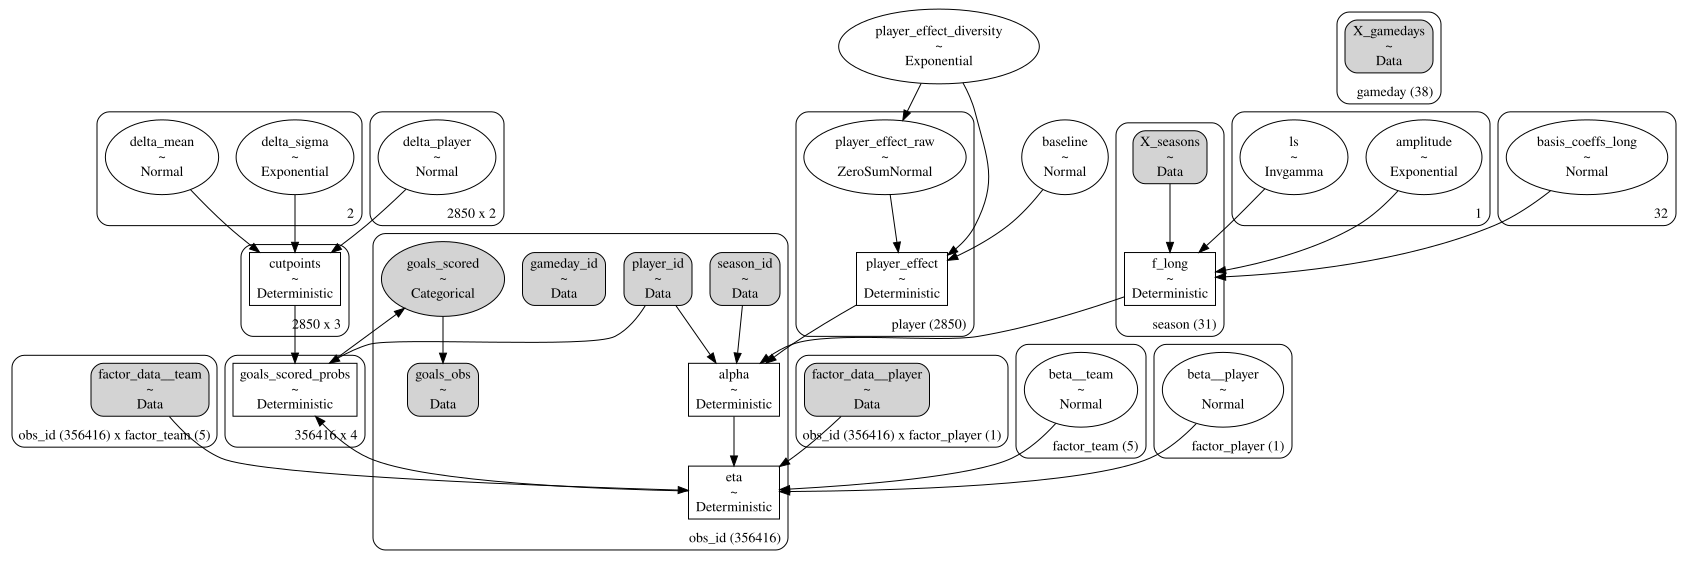

In [40]:
pm.model_to_graphviz(SFM_II__dev)

### 3.5 &emsp; Prior Predictive Sampling

In [41]:
# =============================== Prior Predictive Check (M7.2) =============================== #

with SFM_II__dev:
    idata_prior = pm.sample_prior_predictive(draws=200, var_names=["goals_scored"], random_seed=seed)

# --- Implied category distribution vs. empirical -- if these are orders of magnitude apart,
#     fix the priors BEFORE sampling (referee report M7.2; SFMMO precedent: its check failed
#     formally at 2.6 implied vs 1.37 empirical goals per team-game).
_prior_counts = np.bincount(idata_prior.prior_predictive["goals_scored"].values.ravel(), minlength=4)
_prior_share = _prior_counts / _prior_counts.sum()
_emp_share = complete_data["goals_cats"].value_counts(normalize=True).sort_index().to_numpy()
print(pd.DataFrame({"prior_predictive": _prior_share, "empirical": _emp_share},
                   index=[0, 1, 2, '3+']).round(4))


## 4 &emsp; Inference!

In [42]:
# ============================================= Inference! ============================================= #


# --- In the paper we use 4 chains
# --- Just for speed: set it to 1
N_chains = 2

with SFM_II__dev:
    idata = pm.sample(nuts_sampler="numpyro",
                      target_accept=TARGET_ACCEPT,   # --- M7 + divergence ladder (see USER INTERACTION)
                      chains=N_chains,
                      cores=1,  # --- CPU cores (irrelevant for GPU)
                      draws=200 if SMOKE else 1000,
                      tune=200 if SMOKE else 1000,
                      random_seed=seed,    # --- M7.3: reported numbers must be reproducible
                      nuts_sampler_kwargs={"chain_method": "vectorized"},
                      idata_kwargs={"log_likelihood": True})  # --- Runs chains in parallel on GPU)

if SMOKE:
    print('*** SMOKE MODE (200/200 draws): pipeline test only -- do NOT export or interpret. ***')


sample: 100%|██████████| 2000/2000 [55:20<00:00,  1.66s/it]
/usr/local/lib/python3.12/dist-packages/jax/_src/interpreters/mlir.py:1334: UserWarning: Some donated buffers were not usable: float64[2,1000,2849].
See an explanation at https://docs.jax.dev/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"


In [43]:
# ============================ Convergence Diagnostics (M7.1) ============================ #

# --- Parameters only: obs-sized deterministics (alpha, eta, probs) excluded
# --- FREE parameters only: Deterministics (e.g. the cutpoints' first column, which is the
# --- CONSTANT 4 by construction) have zero within-chain variance -> 0/0 in rhat/mcse and a
# --- flood of RuntimeWarnings. The free RVs below fully determine every Deterministic.
_DETS = {'player_effect', 'f_within', 'f_long', 'f_era', 'cutpoints', 'alpha', 'eta'}
_small_vars = [v for v in idata.posterior.data_vars
               if "obs_id" not in idata.posterior[v].dims and v not in _DETS]
_summ = az.summary(idata, var_names=_small_vars, kind="diagnostics")

_n_div = int(idata.sample_stats["diverging"].sum().values) if "diverging" in idata.sample_stats else -1

print(f"Divergences:  {_n_div}")
print(f"max r_hat:    {_summ['r_hat'].max():.4f}")
print(f"min ess_bulk: {_summ['ess_bulk'].min():.0f}")
print(f"min ess_tail: {_summ['ess_tail'].min():.0f}")

if (_summ['r_hat'].max() > 1.01) or (_summ['ess_bulk'].min() < 100 * len(idata.posterior.chain)) or (_n_div > 0):
    if SMOKE:
        print("\n(not converged -- EXPECTED in SMOKE mode at 200/200 draws; the criterion is that this cell RUNS.)\n")
    else:
        print("\n!!! WARNING: convergence criteria violated -- do NOT interpret results below (referee report M7.1).\n")
    print(_summ.sort_values('r_hat', ascending=False).head(12))


In [45]:
# ============================= Some Preparation for Post-Estimation Processing ============================= #

mindex_coords_original = xr.Coordinates.from_pandas_multiindex(
    complete_data.set_index(["name_player", "season", "gameday"]).index,
    "obs_id",
)

#idata.prior = idata.prior.assign_coords(mindex_coords_original)
#idata.prior_predictive = idata.prior_predictive.assign_coords(mindex_coords_original)
idata.observed_data = idata.observed_data.assign_coords(mindex_coords_original)


with SFM_II__dev:
    idata.extend(pm.sample_posterior_predictive(idata, compile_kwargs={"mode": "NUMBA"}, random_seed=seed))

Output()

In [46]:
#idata.prior = idata.prior.reset_index("obs_id")
#idata.prior_predictive = idata.prior_predictive.reset_index("obs_id")
idata.observed_data = idata.observed_data.reset_index("obs_id")

In [48]:
list(players_ordered).index('cristiano-ronaldo')

527

In [49]:
df_metrics = pd.DataFrame(np.nan,index=['WAIC','LOOCV','logLik','BrierScore','rankedProbScore',
                                        'expCalibError','Acc','ordinalMAE','xGoalsMAE','coverage',
                                        'SAR_mu','SAR_sd'],
                          columns=['SFM','Naive'])

<br>

## 5. &emsp; Evaluation Metrics

<br>

### 5.1 &emsp; In-Sample

In [50]:
# ===================================== WAIC / LOO-CV ===================================== #

waic = az.waic(idata)
print(f'\nWAIC --- SFM:   {waic.values[0]:.2f}')
df_metrics.loc['WAIC','SFM'] = waic.values[0]

loo = az.loo(idata)
print(f'\nLOO-CV --- SFM: {loo.values[0]:.2f}')
df_metrics.loc['LOOCV','SFM'] = loo.values[0]



WAIC --- SFM:   -183350.29

LOO-CV --- SFM: -183356.55


In [51]:
# ===================================== Get Posteriors for Scoring Probabilities ===================================== #

SFM__ins_post = idata['posterior']['goals_scored_probs'].stack(samples=('chain','draw'))
SFM__ins_post = SFM__ins_post.transpose('samples','goals_scored_probs_dim_0','goals_scored_probs_dim_1')


In [52]:
# ===================================== Get Posterior Mean ===================================== #

# --- M3.1 FIX (referee report): the Bayesian predictive distribution is the posterior MEAN
#     over draws; per-category medians need not sum to 1 and bias every downstream metric.
SFM__ins_post__mean = SFM__ins_post.mean(dim='samples')


In [53]:
# ===================================== Prepare the Predictions ===================================== #

# --- SFM:
Y__SFM = idata['observed_data']['goals_scored'].to_numpy()
Yhat__SFM = SFM__ins_post__mean.to_numpy()


# --- Benchmark: marginal-frequency naive (M3.3 FIX -- replaces the degenerate P(0)=1
#     predictor, which wins the MAE-family metrics by construction and whose log-lik
#     was an artifact of the log-epsilon)
Yhat__N_0 = np.tile(empirical_probs, (len(Y__SFM), 1))


In [54]:
# ============================================= Metrics ============================================= #


# ------------------------------------ Log-Likelihood ------------------------------------ #
"""
    - Rewards models that assign high probability to what actually happened
    - Penalizes overconfident wrong predictions heavily
    - Natural fit for Bayesian models

"""
df_metrics.loc['logLik','SFM'] = compute_log_likelihood(Yhat__SFM, Y__SFM)
df_metrics.loc['logLik','Naive'] = compute_log_likelihood(Yhat__N_0, Y__SFM)

print('\n')
print(f'Log-Likelihood --- SFM:  {df_metrics.loc['logLik','SFM']:.2f}')
print(f'Log-Likelihood --- N_0:  {df_metrics.loc['logLik','Naive']:.2f}')



# ------------------------------------ Multi-Class Brier Score ------------------------------------ #
"""
    - Random guessing (uniform): ~0.75
    - Decent model: 0.3-0.5
    - Great model: 0.2-0.3
    - Perfect: 0.0

"""

df_metrics.loc['BrierScore','SFM'] = multi_class_brier_score(Yhat__SFM, Y__SFM, n_classes=4)
df_metrics.loc['BrierScore','Naive'] = multi_class_brier_score(Yhat__N_0, Y__SFM, n_classes=4)


print('\n')
print(f'Multi-Class Brier-Score --- SFM:  {df_metrics.loc['BrierScore','SFM']:.2f}')
print(f'Multi-Class Brier-Score --- N_0:  {df_metrics.loc['BrierScore','Naive']:.2f}')




# ------------------------------------ Ranked Probability Score ------------------------------------ #
"""
    - Industry Standard for Ordinal Regressions
    - Penalizes being "far off" more than Brier Score
    - Used in weather forecasting, sports analytics

"""

df_metrics.loc['rankedProbScore','SFM'] = ranked_probability_score(Yhat__SFM, Y__SFM, n_classes=4)
df_metrics.loc['rankedProbScore','Naive'] = ranked_probability_score(Yhat__N_0, Y__SFM, n_classes=4)


print('\n')
print(f'Ranked-Probability-Score --- SFM:  {df_metrics.loc['rankedProbScore','SFM']:.2f}')
print(f'Ranked-Probability-Score --- N_0:  {df_metrics.loc['rankedProbScore','Naive']:.2f}')


# ------------------------------------ Expected Calibration Error ------------------------------------ #
"""
    - Are probabilities well calibrated? (---> "Of all times you said 30% chance, did it happen ~30% of the time?")


"""

df_metrics.loc['expCalibError','SFM'] = expected_calibration_error(Yhat__SFM, Y__SFM)
df_metrics.loc['expCalibError','Naive'] = expected_calibration_error(Yhat__N_0, Y__SFM)

print('\n')
print(f'Expected Calibration Error --- SFM:  {df_metrics.loc['expCalibError','SFM']:.2f}')
print(f'Expected Calibration Error --- N_0:  {df_metrics.loc['expCalibError','Naive']:.2f}')



# ------------------------------------ Accuracy ------------------------------------ #
"""
    - "Our model correctly predicts goals 67% of the time"
    - Doesn't distinguish between "50% confident and right" vs "95% confident and right"

"""

df_metrics.loc['Acc','SFM'] = ordinal_accuracy(Yhat__SFM, Y__SFM)
df_metrics.loc['Acc','Naive'] = ordinal_accuracy(Yhat__N_0, Y__SFM)

print('\n')
print(f'Accuracy --- SFM:  {df_metrics.loc['Acc','SFM']:.2f}')
print(f'Accuracy --- N_0:  {df_metrics.loc['Acc','Naive']:.2f}')



# ------------------------------------ Ordinal MAE ------------------------------------ #
"""
    - MAE = 0.5 ---> on average, off by half a goal
"""

df_metrics.loc['ordinalMAE','SFM'] = ordinal_mae(Yhat__SFM, Y__SFM)
df_metrics.loc['ordinalMAE','Naive'] = ordinal_mae(Yhat__N_0, Y__SFM)

print('\n')
print(f'Ordinal MAE --- SFM:  {df_metrics.loc['ordinalMAE','SFM']:.2f}')
print(f'Ordinal MAE --- N_0:  {df_metrics.loc['ordinalMAE','Naive']:.2f}')



# ------------------------------------ Expected Goals MAE ------------------------------------ #
"""

"""

df_metrics.loc['xGoalsMAE','SFM'] = xGoals_mae(Yhat__SFM, Y__SFM)
df_metrics.loc['xGoalsMAE','Naive'] = xGoals_mae(Yhat__N_0, Y__SFM)

print('\n')
print(f'Expected Goals MAE --- SFM:  {df_metrics.loc['xGoalsMAE','SFM']:.2f}')
print(f'Expected Goals MAE --- N_0:  {df_metrics.loc['xGoalsMAE','Naive']:.2f}')


print('\n\n\n')



Log-Likelihood --- SFM:  -181282.36
Log-Likelihood --- N_0:  -1427142.24


Multi-Class Brier-Score --- SFM:  0.28
Multi-Class Brier-Score --- N_0:  0.35


Ranked-Probability-Score --- SFM:  0.16
Ranked-Probability-Score --- N_0:  0.20


Expected Calibration Error --- SFM:  0.01
Expected Calibration Error --- N_0:  0.00


Accuracy --- SFM:  0.83
Accuracy --- N_0:  0.83


Ordinal MAE --- SFM:  0.20
Ordinal MAE --- N_0:  0.20


Expected Goals MAE --- SFM:  0.31
Expected Goals MAE --- N_0:  0.20






In [55]:
# ===================================== Coverage Statistic ===================================== #

print(f'\n--------------------------- Selected Model: SFM II Dev{devVersion} --------------------------- \n')
y_hdi = az.hdi(idata.posterior_predictive["goals_scored"])
y_obs = idata["observed_data"]["goals_scored"].to_numpy()
is_within_hdi = (y_obs >= y_hdi.sel(hdi='lower')["goals_scored"].to_numpy()) & (y_obs <= y_hdi.sel(hdi='higher')["goals_scored"].to_numpy())
print(f'Posterior 94% HDIs coverage: {np.round(is_within_hdi.mean()*100,2)}%')

df_metrics.loc['coverage','SFM'] = is_within_hdi.mean()*100

# --- PIT / coverage via ArviZ (M3 FIX: the HDI-coverage print above is near-vacuous for a
#     4-category outcome where P(y<=1) = 0.977 -- keep it only as a footnote)
try:
    azp.plot_ppc_pit(idata,
                    coverage=True,
                    visuals={"ylabel":False},
                    figure_kwargs={"sharey":True},
                    );
except Exception as _e:
    print(f"plot_ppc_pit unavailable/failed: {_e}")



--------------------------- Selected Model: SFM II DevM --------------------------- 

Posterior 94% HDIs coverage: 98.15%


<br>

### 5.2 &emsp; Out-of-Sample

In [56]:
# ===================================== OOS ===================================== #

# --- Goal Categories
data_oos["goals_cats"] = np.where(
    data_oos["goals_in_match"] >= 3, 3, data_oos["goals_in_match"]
)

# --- Some Game-Day-Adjustments are necessary
data_oos['gameday_orig'] = data_oos['gameday'].copy()
data_oos['gameday'] = [int(float(i.split('_')[1][2:])) for i in data_oos['id_match'].values]


# --- Cross-Sectional Scaling:
if do__scaleCS:
  # --- factor-wise scaling (same fix as the training cell; _cs_scale is defined there)
  data_oos__scaleCS = data_oos.groupby('gameday')[factors_CS].apply(_cs_scale).reset_index().set_index('level_1').drop('gameday',axis=1)


  # --- Merge:
  data_oos[factors_CS] = data_oos__scaleCS


# --- Index for Game Days:
gameday_idx__OOS = pd.Categorical(
    data_oos["gameday"],
    categories=unique_gamedays,
).codes


# --- Types of HSGP timescales:
if devVersion in ['B','D','F','G','L','M','N','P','Q','R','U']:
  timescale = ['long']
else:
  timescale = ['short', 'medium', 'long']


In [57]:
params_HSGP = {'lengthscales': {'short': ls_short_dist, 'medium': ls_medium_dist, 'long': ls_long_dist},
                                      'basis_vectors': {'within': None, 'long': m_long},
                                      'scaling_factors': {'within': None, 'long': c_long},
               'devVersion': devVersion}

In [58]:
# ------------- PLAYERS:

def get__PlayerIndexNew(series):
    ordered = pd.Index(sorted(series.unique()))
    idx = pd.Categorical(series, categories=ordered).codes
    return idx, ordered

def get__PlayerIndexOld(series, orderOld):
    order = [i for i in orderOld if i in series.unique()]
    idx = pd.Categorical(series, categories=orderOld).codes
    return idx, order


# --- Players ... ALL:
players_ordered__OOS = data_oos["name_player"].sort_values().unique()


# --- Index for EXISTING Players:
data_idx__OOS_same = data_oos.loc[data_oos['name_player'].isin(complete_data['name_player'].values),:].index
player_idx__OOS_same, players_ordered__OOS_same = get__PlayerIndexOld(data_oos.loc[data_idx__OOS_same,'name_player'],
                                                                        orderOld=players_ordered)



# --- Index for NEW Players:
data_idx__OOS_new = data_oos.loc[~(data_oos['name_player'].isin(complete_data['name_player'].values)),:].index
player_idx__OOS_new, players_ordered__OOS_new = get__PlayerIndexNew(data_oos.loc[data_idx__OOS_new,'name_player'])



In [59]:
any([players_ordered__OOS_new[i] in complete_data['name_player'].values for i in np.unique(player_idx__OOS_new)])

False

In [60]:
def get__CrossSeasonalVariation(model, hsgp_params, data):
    """
    Reconstruct the cross-seasonal (long-term) GP for new season values.
    Uses the fitted hyperparameters from training but evaluates at new season points.
    """

    # --- Reconstruct covariance function from fitted hyperparameters ---
    amplitude = model.amplitude
    ls = model.ls

    if hsgp_params['devVersion'] in ['B','D','F','G','L','M','N','P','Q','R','U']:
      cov_long = amplitude ** 2 * pm.gp.cov.Matern52(input_dim=1, ls=ls)
    else:
      cov_long = amplitude[2] ** 2 * pm.gp.cov.Matern52(input_dim=1, ls=ls[2])

    # --- Recreate HSGP with SAME m, c as training ---
    gp_long__new = pm.gp.HSGP(
        m=[hsgp_params['basis_vectors']['long']],
        c=hsgp_params['scaling_factors']['long'],
        cov_func=cov_long
    )

    # --- Evaluate basis functions at NEW input points ---
    basis_long__new, sqrt_psd_long__new = gp_long__new.prior_linearized(X=data)

    # --- Compute GP values using FITTED basis coefficients ---
    f_long__new = pm.Deterministic(
        "f_long__new",
        basis_long__new @ (model.basis_coeffs_long * sqrt_psd_long__new),
        dims="season__new",
    )

    return f_long__new


In [61]:
import copy

In [62]:
SFM_II__newP = copy.deepcopy(SFM_II__dev)
SFM_II__sameP = copy.deepcopy(SFM_II__dev)

In [63]:
# --------- NEW PLAYERS


# --- Gameday Index:
gameday_unique__OOS = np.arange(1, 39)  # Fixed gameday range as in notebook
gameday_idx__OOS_new = pd.Categorical(
    data_oos.loc[data_idx__OOS_new,'gameday'],
    categories=gameday_unique__OOS
).codes

# --- Seasons:
season_unique__OOS = np.arange(0, 31)  # Fixed season range as in notebook
season_idx__new = data_oos.loc[data_idx__OOS_new,"season_nbr"].to_numpy()

with SFM_II__newP:


    SFM_II__newP.add_coord("player__new", players_ordered__OOS_new)
    SFM_II__newP.add_coord("obs_id__new", data_oos.loc[data_idx__OOS_new,:].index)

    SFM_II__newP.add_coord("gameday__new", gameday_unique__OOS)
    SFM_II__newP.add_coord("season__new", season_unique__OOS)

    # --- Update the Model Data:
    X_gamedays__new = pm.Data("X_gamedays__new", gameday_unique__OOS, dims="gameday__new")[:, None]
    X_seasons__new = pm.Data("X_seasons__new", season_unique__OOS, dims="season__new")[:, None]


    # --- Factor data container (single factor_data)
    factor_data__new_team = pm.Data(
        "factor_data__new_team", data_oos.loc[data_idx__OOS_new,factors_team].to_numpy(), dims=("obs_id__new", "factor_team")
    )

    if devVersion in ['A','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','U','V','W','X']:
      factor_data__new_player = pm.Data(
          "factor_data__new_player", data_oos.loc[data_idx__OOS_new,factors_player].to_numpy(), dims=("obs_id__new", "factor_player")
      )

    gameday_id__new = pm.Data("gameday_id__new", gameday_idx__OOS_new, dims="obs_id__new")
    player_id__new = pm.Data("player_id__new", player_idx__OOS_new, dims="obs_id__new")
    season_id__new = pm.Data("season_id__new", data_oos.loc[data_idx__OOS_new,"season_nbr"].values, dims="obs_id__new")
    goals_obs__new = pm.Data("goals_obs__new", np.zeros(len(data_idx__OOS_new), dtype=np.int64), dims="obs_id__new")

    # --- Baseline Skill (using fitted parameters)
    intercept_sigma = 5
    sd = SFM_II__newP.player_effect_diversity
    # --- M2.1 FIX (referee report): training defines the effective baseline as
    #     baseline_sigma * Normal("baseline"), baseline_sigma = sqrt(5^2 + sd^2 / N_train_players).
    #     Reusing the raw node shifted every new player's eta by (1 - baseline_sigma)*z ~ -4z
    #     (~ -2 logits, a ~6x under-prediction of scoring). The multiplier must match TRAINING
    #     exactly, so N = len(players_ordered), NOT the number of new players.
    baseline_sigma = pt.sqrt(intercept_sigma ** 2 + sd ** 2 / len(players_ordered))
    baseline = baseline_sigma * SFM_II__newP.baseline

    # --- Player-Effect: Baseline + Zero-Sum Normal (new players get new random effects)
    player_effect = pm.Deterministic(
        "player_effect__new",
        baseline + pm.ZeroSumNormal("player_effect_raw__new", sigma=sd, dims="player__new"),
        dims="player__new",
    )


    if devVersion in ['B','D','F','G','L','M','N','P','Q','R','U']:

      # --- GPs: Cross-Seasonal Variation (reconstruct for potentially new seasons)
      f_long = get__CrossSeasonalVariation(SFM_II__newP, params_HSGP, X_seasons__new)

      # --- Player's Alpha:
      alpha = pm.Deterministic(
          "alpha__new",
          player_effect[player_id__new] + f_long[season_id__new],
          dims="obs_id__new",
      )

    elif devVersion in ['C','E','OG','I','J','K','O','S','V','W','X']:

      # --- GPs: Within-Season Variation (use fitted f_within from training)
      f_within = SFM_II__newP.f_within

      # --- GPs: Cross-Seasonal Variation (reconstruct for potentially new seasons)
      f_long = get__CrossSeasonalVariation(SFM_II__newP, params_HSGP, X_seasons__new)

      # --- Player's Alpha:
      alpha = pm.Deterministic(
          "alpha__new",
          player_effect[player_id__new] + f_within[gameday_id__new] + f_long[season_id__new],
          dims="obs_id__new",
      )


    elif devVersion in ['A','H']:

      # --- Player's Alpha:
      alpha = pm.Deterministic(
          "alpha__new",
          player_effect[player_id__new],
          dims="obs_id__new",
      )


    # --- Team Factors (use fitted slope from training)
    beta__team = SFM_II__newP.beta__team

    # --- M2.2 FIX (referee report): the pooled beta__player is a GLOBAL fitted coefficient --
    #     reuse the trained node (exactly like beta__team above). Redrawing it under a new name
    #     made sample_posterior_predictive draw it from the PRIOR N(0, 2.5).
    if devVersion in ['A','F','G','H','I','J','K','L','M','N','O','Q','V']:
      beta__player = SFM_II__newP.beta__player
    elif devVersion in ['P','R','S','U']:
      # player-specific: new players have no fitted coefficient; a prior draw is the honest
      # predictive here (NOTE: unpooled by construction -- see referee report M1.3)
      beta__player = pm.Normal("beta__player_new", sigma=2.5, dims=('player__new','factor_player'))
    elif devVersion in ['W','X']:
      beta__player = pm.HalfNormal("beta__player_new", sigma=0.5, dims=('player__new','factor_player'))


    # --- Conditional Mean:
    if devVersion in ['A','F','G','H','I','J','K','L','M','N','O','Q','V']:
      eta = pm.Deterministic(
        "eta__new", alpha + (factor_data__new_player * beta__player).sum(axis=-1) + pm.math.dot(factor_data__new_team, beta__team), dims="obs_id__new"
      )
    elif devVersion in ['P','R','S','U','W','X']:
      eta = pm.Deterministic(
        "eta__new", alpha + (factor_data__new_player * beta__player[player_id__new,:]).sum(axis=-1) + pm.math.dot(factor_data__new_team, beta__team), dims="obs_id__new"
      )
    else:
      eta = pm.Deterministic(
        "eta__new", alpha + pm.math.dot(factor_data__new_team, beta__team), dims="obs_id__new"
      )







    # --- Hyperpriors for the differences between cutpoints (delta)
    cutpoint_offset = 4
    # --- --- Mean of differences across all players (use fitted)
    delta_mean = SFM_II__newP.delta_mean
    # --- --- Variation of the differences (use fitted)
    delta_sigma = SFM_II__newP.delta_sigma


    # --- Player-specific differences (delta) - new players get new cutpoint adjustments
    delta_player = delta_mean + delta_sigma * pm.Normal("delta_player__new", shape=(len(players_ordered__OOS_new), 2))

    # Cumulative sum to construct cutpoints
    # Ensure differences are positive using softplus
    cutpoints = pm.Deterministic(
        "cutpoints__new",
        pt.concatenate(
            [
                pt.full((player_effect.shape[0], 1), cutpoint_offset),
                pt.cumsum(pt.softplus(delta_player), axis=-1) + cutpoint_offset,
            ],
            axis=-1,
        ),  # Start at cutpoint_offset and sum differences
    )


    # --- Likelihood:
    pm.OrderedLogistic(
        "goals_scored__new",
        cutpoints=cutpoints[player_id__new],
        eta=eta,
        observed=goals_obs__new,
        dims="obs_id__new",
    )

In [64]:
# --------- SAME PLAYERS

# --- Gameday Index:
gameday_idx__OOS_same = pd.Categorical(
    data_oos.loc[data_idx__OOS_same,'gameday'],
    categories=gameday_unique__OOS
).codes

# --- Seasons:
season_idx__new = data_oos.loc[data_idx__OOS_same,"season_nbr"].to_numpy()


with SFM_II__sameP:

    if devVersion in ['A','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','U','V','W','X']:
      pm.set_data(

          coords = {"obs_id": data_oos.loc[data_idx__OOS_same,:].index},
          new_data = {
              "season_id": data_oos.loc[data_idx__OOS_same,"season_nbr"].values,
              "gameday_id": gameday_idx__OOS_same,
              "player_id": player_idx__OOS_same,
              "factor_data__team": data_oos.loc[data_idx__OOS_same,factors_team].values,
              "factor_data__player": data_oos.loc[data_idx__OOS_same,factors_player].values,
              # --- Just a placeholder
              "goals_obs": np.zeros(len(data_idx__OOS_same), dtype=np.int64),
          }

      )

    else:
      pm.set_data(

          coords = {"obs_id": data_oos.loc[data_idx__OOS_same,:].index},
          new_data = {
              "season_id": data_oos.loc[data_idx__OOS_same,"season_nbr"].values,
              "gameday_id": gameday_idx__OOS_same,
              "player_id": player_idx__OOS_same,
              "factor_data__team": data_oos.loc[data_idx__OOS_same,factors_team].values,
              # --- Just a placeholder
              "goals_obs": np.zeros(len(data_idx__OOS_same), dtype=np.int64),
          }

      )

In [65]:
# -------------------------- Step 6: Sample from the Posterior! -------------------------- #


with SFM_II__sameP:

    oos_preds__same = pm.sample_posterior_predictive(
            idata,
            var_names=["alpha", "eta", "goals_scored", 'goals_scored_probs'],
            predictions=True,
            compile_kwargs={"mode": "NUMBA"},
            random_seed = seed,
        )



with SFM_II__newP:

    oos_preds__new = pm.sample_posterior_predictive(
            idata,
            var_names=["alpha", "eta", "goals_scored", 'goals_scored_probs',
                        "alpha__new", "eta__new", "goals_scored__new","goals_scored__new_probs"],
            predictions=True,
            compile_kwargs={"mode": "NUMBA"},
            random_seed = seed,
        )

Output()

Output()

In [66]:
oos_preds__new['predictions']['goals_scored__new_probs'].shape[2] + oos_preds__same['predictions']['goals_scored_probs'].shape[2] == data_oos.shape[0]

True

In [67]:
dict_metrics__OOS = {key: pd.DataFrame(np.nan,index=['logLik','BrierScore','rankedProbScore',
                                             'expCalibError','Acc','ordinalMAE','xGoalsMAE'],
                               columns=['SFM','Naive']) for key in ['oos','oos_newP','oos_sameP']}


In [68]:
# ===================================== Get Posteriors for Scoring Probabilities ===================================== #

# --- New Players:
SFM__oos_post__new = oos_preds__new['predictions']['goals_scored__new_probs'].stack(samples=('chain','draw'))
SFM__oos_post__new = SFM__oos_post__new.transpose('samples','goals_scored__new_probs_dim_0','goals_scored__new_probs_dim_1')

# --- Existing Players:
SFM__oos_post__same = oos_preds__same['predictions']['goals_scored_probs'].stack(samples=('chain','draw'))
SFM__oos_post__same = SFM__oos_post__same.transpose('samples','goals_scored_probs_dim_0','goals_scored_probs_dim_1')

# --- Posterior Mean (M3.1 FIX: the Bayesian predictive is the mean over draws;
#     per-category medians need not sum to 1):

SFM__oos_post__new__mean = SFM__oos_post__new.mean(dim='samples')
SFM__oos_post__same__mean = SFM__oos_post__same.mean(dim='samples')


In [69]:
# ===================================== Prepare the Predictions ===================================== #

# --- New Players:
Y__OOS_new = data_oos.loc[data_idx__OOS_new,'goals_cats'].to_numpy()
Yhat__OOS_new = SFM__oos_post__new__mean.to_numpy()

# --- Existing Players:
Y__OOS_same = data_oos.loc[data_idx__OOS_same,'goals_cats'].to_numpy()
Yhat__OOS_same = SFM__oos_post__same__mean.to_numpy()

# --- All Players:
Y__OOS = data_oos.loc[np.concatenate((data_idx__OOS_same,data_idx__OOS_new)),'goals_cats'].to_numpy()
Yhat__OOS = np.concatenate((SFM__oos_post__same__mean.to_numpy(),SFM__oos_post__new__mean.to_numpy()))


# --- Benchmark: marginal-frequency naive (M3.3 FIX -- see the in-sample cell)
Yhat_new__N_0 = np.tile(empirical_probs, (len(Y__OOS_new), 1))
Yhat_same__N_0 = np.tile(empirical_probs, (len(Y__OOS_same), 1))
Yhat__N_0 = np.tile(empirical_probs, (len(Y__OOS), 1))


In [70]:
# ============================================= Metrics ============================================= #


# ------------------------------------ Log-Likelihood ------------------------------------ #
"""
    - Rewards models that assign high probability to what actually happened
    - Penalizes overconfident wrong predictions heavily
    - Natural fit for Bayesian models

"""
dict_metrics__OOS['oos'].loc['logLik','SFM'] = compute_log_likelihood(Yhat__OOS, Y__OOS)
dict_metrics__OOS['oos'].loc['logLik','Naive'] = compute_log_likelihood(Yhat__N_0, Y__OOS)

dict_metrics__OOS['oos_newP'].loc['logLik','SFM'] = compute_log_likelihood(Yhat__OOS_new, Y__OOS_new)
dict_metrics__OOS['oos_newP'].loc['logLik','Naive'] = compute_log_likelihood(Yhat_new__N_0, Y__OOS_new)

dict_metrics__OOS['oos_sameP'].loc['logLik','SFM'] = compute_log_likelihood(Yhat__OOS_same, Y__OOS_same)
dict_metrics__OOS['oos_sameP'].loc['logLik','Naive'] = compute_log_likelihood(Yhat_same__N_0, Y__OOS_same)


# ------------------------------------ Multi-Class Brier Score ------------------------------------ #
"""
    - Random guessing (uniform): ~0.75
    - Decent model: 0.3-0.5
    - Great model: 0.2-0.3
    - Perfect: 0.0

"""

dict_metrics__OOS['oos'].loc['BrierScore','SFM'] = multi_class_brier_score(Yhat__OOS, Y__OOS, n_classes=4)
dict_metrics__OOS['oos'].loc['BrierScore','Naive'] = multi_class_brier_score(Yhat__N_0, Y__OOS, n_classes=4)

dict_metrics__OOS['oos_newP'].loc['BrierScore','SFM'] = multi_class_brier_score(Yhat__OOS_new, Y__OOS_new, n_classes=4)
dict_metrics__OOS['oos_newP'].loc['BrierScore','Naive'] = multi_class_brier_score(Yhat_new__N_0, Y__OOS_new, n_classes=4)

dict_metrics__OOS['oos_sameP'].loc['BrierScore','SFM'] = multi_class_brier_score(Yhat__OOS_same, Y__OOS_same, n_classes=4)
dict_metrics__OOS['oos_sameP'].loc['BrierScore','Naive'] = multi_class_brier_score(Yhat_same__N_0, Y__OOS_same, n_classes=4)





# ------------------------------------ Ranked Probability Score ------------------------------------ #
"""
    - Industry Standard for Ordinal Regressions
    - Penalizes being "far off" more than Brier Score
    - Used in weather forecasting, sports analytics

"""

dict_metrics__OOS['oos'].loc['rankedProbScore','SFM'] = ranked_probability_score(Yhat__OOS, Y__OOS, n_classes=4)
dict_metrics__OOS['oos'].loc['rankedProbScore','Naive'] = ranked_probability_score(Yhat__N_0, Y__OOS, n_classes=4)

dict_metrics__OOS['oos_newP'].loc['rankedProbScore','SFM'] = ranked_probability_score(Yhat__OOS_new, Y__OOS_new, n_classes=4)
dict_metrics__OOS['oos_newP'].loc['rankedProbScore','Naive'] = ranked_probability_score(Yhat_new__N_0, Y__OOS_new, n_classes=4)

dict_metrics__OOS['oos_sameP'].loc['rankedProbScore','SFM'] = ranked_probability_score(Yhat__OOS_same, Y__OOS_same, n_classes=4)
dict_metrics__OOS['oos_sameP'].loc['rankedProbScore','Naive'] = ranked_probability_score(Yhat_same__N_0, Y__OOS_same, n_classes=4)



# ------------------------------------ Expected Calibration Error ------------------------------------ #
"""
    - Are probabilities well calibrated? (---> "Of all times you said 30% chance, did it happen ~30% of the time?")


"""

dict_metrics__OOS['oos'].loc['expCalibError','SFM'] = expected_calibration_error(Yhat__OOS, Y__OOS)
dict_metrics__OOS['oos'].loc['expCalibError','Naive'] = expected_calibration_error(Yhat__N_0, Y__OOS)

dict_metrics__OOS['oos_newP'].loc['expCalibError','SFM'] = expected_calibration_error(Yhat__OOS_new, Y__OOS_new)
dict_metrics__OOS['oos_newP'].loc['expCalibError','Naive'] = expected_calibration_error(Yhat_new__N_0, Y__OOS_new)

dict_metrics__OOS['oos_sameP'].loc['expCalibError','SFM'] = expected_calibration_error(Yhat__OOS_same, Y__OOS_same)
dict_metrics__OOS['oos_sameP'].loc['expCalibError','Naive'] = expected_calibration_error(Yhat_same__N_0, Y__OOS_same)



# ------------------------------------ Accuracy ------------------------------------ #
"""
    - "Our model correctly predicts goals 67% of the time"
    - Doesn't distinguish between "50% confident and right" vs "95% confident and right"

"""

dict_metrics__OOS['oos'].loc['Acc','SFM'] = ordinal_accuracy(Yhat__OOS, Y__OOS)
dict_metrics__OOS['oos'].loc['Acc','Naive'] = ordinal_accuracy(Yhat__N_0, Y__OOS)

dict_metrics__OOS['oos_newP'].loc['Acc','SFM'] = ordinal_accuracy(Yhat__OOS_new, Y__OOS_new)
dict_metrics__OOS['oos_newP'].loc['Acc','Naive'] = ordinal_accuracy(Yhat_new__N_0, Y__OOS_new)

dict_metrics__OOS['oos_sameP'].loc['Acc','SFM'] = ordinal_accuracy(Yhat__OOS_same, Y__OOS_same)
dict_metrics__OOS['oos_sameP'].loc['Acc','Naive'] = ordinal_accuracy(Yhat_same__N_0, Y__OOS_same)



# ------------------------------------ Ordinal MAE ------------------------------------ #
"""
    - MAE = 0.5 ---> on average, off by half a goal
"""

dict_metrics__OOS['oos'].loc['ordinalMAE','SFM'] = ordinal_mae(Yhat__OOS, Y__OOS)
dict_metrics__OOS['oos'].loc['ordinalMAE','Naive'] = ordinal_mae(Yhat__N_0, Y__OOS)

dict_metrics__OOS['oos_newP'].loc['ordinalMAE','SFM'] = ordinal_mae(Yhat__OOS_new, Y__OOS_new)
dict_metrics__OOS['oos_newP'].loc['ordinalMAE','Naive'] = ordinal_mae(Yhat_new__N_0, Y__OOS_new)

dict_metrics__OOS['oos_sameP'].loc['ordinalMAE','SFM'] = ordinal_mae(Yhat__OOS_same, Y__OOS_same)
dict_metrics__OOS['oos_sameP'].loc['ordinalMAE','Naive'] = ordinal_mae(Yhat_same__N_0, Y__OOS_same)



# ------------------------------------ Expected Goals MAE ------------------------------------ #
"""

"""

dict_metrics__OOS['oos'].loc['xGoalsMAE','SFM'] = xGoals_mae(Yhat__OOS, Y__OOS)
dict_metrics__OOS['oos'].loc['xGoalsMAE','Naive'] = xGoals_mae(Yhat__N_0, Y__OOS)

dict_metrics__OOS['oos_newP'].loc['xGoalsMAE','SFM'] = xGoals_mae(Yhat__OOS_new, Y__OOS_new)
dict_metrics__OOS['oos_newP'].loc['xGoalsMAE','Naive'] = xGoals_mae(Yhat_new__N_0, Y__OOS_new)

dict_metrics__OOS['oos_sameP'].loc['xGoalsMAE','SFM'] = xGoals_mae(Yhat__OOS_same, Y__OOS_same)
dict_metrics__OOS['oos_sameP'].loc['xGoalsMAE','Naive'] = xGoals_mae(Yhat_same__N_0, Y__OOS_same)


print('\nFine.\n\n')


Fine.




<br>

## 6. &emsp; SAR & PAR

**Estimand (M5, decided 2026-08-04):** PAR = performance above the **average player** under
*observed* context. SAR = skill above the average player under *equalized* context (standardized
context factors at their cross-sectional average; average schedule), **holding the player's
attributes** (position, cumulative output) at observed values, with momentum at the player's
**historical average** (headline `SAR`) or at the **population average** (`SAR_formneutral`).
SAR − PAR therefore isolates the team-context contribution. Replacement level = average player —
a documented deviation from the paper. Note: goal categories are capped at 3+, so elite scorers'
rates are slightly understated.

In [71]:
# ================================= Coordinate Bookkeeping ================================= #
# --- M7.4 FIX: the duplicate posterior-predictive sampling was removed here -- the group was
#     already sampled in the in-sample section, and InferenceData.extend silently kept the
#     existing group anyway (the resample was pure waste).

mindex_coords_original = idata.observed_data.coords



idata.posterior = idata.posterior.assign_coords(mindex_coords_original)
idata.posterior_predictive = idata.posterior_predictive.assign_coords(
    mindex_coords_original
)
idata.observed_data = idata.observed_data.assign_coords(mindex_coords_original)

idata.posterior = idata.posterior.rename({"goals_scored_probs_dim_1": "event"})

Output()

In [72]:
# ================================= PAR: Performance Above Replacement ================================= #

"""
    Replacement level = AVERAGE PLAYER -- a documented deviation from the paper
    (decided 2026-08-04; referee report M5). PAR conditions on OBSERVED context.
"""

post_preds = idata.posterior_predictive['goals_scored'].reset_index("obs_id")

PAR = (
    post_preds.groupby("name_player").mean("obs_id") - post_preds.mean("obs_id")
).rename("PAR")


In [73]:
# ============================ SAR Counterfactual: Equalize CONTEXT, hold player ATTRIBUTES ============================ #
#
# Estimand (referee report M5; decided 2026-08-04):
#   equalized ("all teams equal"):
#     - standardized CONTEXT factors -> 0   (= cross-sectional average; valid because CS-standardized)
#     - home_pitch                   -> empirical mean (average schedule -- NOT 0 = "all away")
#   held at OBSERVED values (player attributes, not context):
#     - position dummies, cumulative player goals, player share
#   momentum -- two counterfactuals, NEITHER uses the current value:
#     - player's HISTORICAL AVERAGE momentum -> "SAR"             (headline)
#     - population-average momentum          -> "SAR_formneutral"
#
# The old cell zeroed the whole factor_data__team container -- i.e. "every match away, every
# player recoded to the reference position" (report M5). This cell implements the caption.

CONTEXT_FACTORS = ['points_diff', 'goal_appeal', 'goalsconceded_rank_opp']

X_team_cf = factors_sdz[factors_team].copy()
for f in factors_team:
    if (f in CONTEXT_FACTORS) and (f in factors_CS):
        X_team_cf[f] = 0.0                      # standardized context -> cross-sectional average
    elif f == 'home_pitch':
        X_team_cf[f] = X_team_cf[f].mean()      # average schedule
    # else: held at observed (positions, cumulative output)

counterfacts = {}
with SFM_II__dev:
    pm.set_data({"factor_data__team": X_team_cf.to_numpy()})

    if len(factors_player) > 0:
        mom_obs = factors_sdz[factors_player[0]]
        # --- player's historical average momentum (their own typical form level)
        mom_player_hist = mom_obs.groupby(complete_data['name_player']).transform('mean')
        pm.set_data({"factor_data__player": mom_player_hist.to_numpy()[:, None]})

    counterfacts['SAR'] = pm.sample_posterior_predictive(
        idata, var_names=["goals_scored"], predictions=True,
        compile_kwargs={"mode": "NUMBA"}, random_seed=seed)

if len(factors_player) > 0:
    with SFM_II__dev:
        # --- population-average momentum (form-neutral)
        pm.set_data({"factor_data__player": np.full((len(mom_obs), 1), float(mom_obs.mean()))})
        counterfacts['SAR_formneutral'] = pm.sample_posterior_predictive(
            idata, var_names=["goals_scored"], predictions=True,
            compile_kwargs={"mode": "NUMBA"}, random_seed=seed)


Output()

In [74]:
# ================================= SAR / SAR_formneutral ================================= #

"""
    Replacement level = AVERAGE PLAYER (documented deviation from the paper; report M5).
    SAR units: capped goals per game above the average player (3+ cap slightly understates
    elite scorers -- stated for the record).
"""

def _sar_from(cf_preds, name):
    cf_preds.predictions = cf_preds.predictions.assign_coords(mindex_coords_original)
    p = cf_preds.predictions["goals_scored"].reset_index("obs_id")
    return (p.groupby("name_player").mean("obs_id") - p.mean("obs_id")).rename(name)

SAR = _sar_from(counterfacts['SAR'], "SAR")
SAR_formneutral = (_sar_from(counterfacts['SAR_formneutral'], "SAR_formneutral")
                   if 'SAR_formneutral' in counterfacts else None)

diff = SAR - PAR

# --- Average SAR by Player:
pSAR__mu = SAR.mean(("chain", "draw"))

# --- Store some descriptive Stats:
df_metrics.loc['SAR_mu','SFM'] = pSAR__mu.mean().values
df_metrics.loc['SAR_sd','SFM'] = pSAR__mu.std().values


In [75]:
# ================================= Plotting ================================= #

PLAYER_SUBSET = SAR.sortby(SAR.median(dim=['chain','draw']), ascending=False)['name_player'][:20]
#PLAYER_SUBSET = diff.sortby(diff.median(dim=['chain','draw']), ascending=False)['name_player'][:20]


SAR_plot = SAR.where(SAR["name_player"].isin(PLAYER_SUBSET), drop=True)#.rename("")
diff_plot = diff.where(diff["name_player"].isin(PLAYER_SUBSET), drop=True)#.rename("")

SAR_mean = SAR_plot.mean(("chain", "draw"))

# sort indices based on means in descending order
sorted_indices = np.argsort(-SAR_mean.to_numpy())

# reorder based on sorted indices
sorted_SAR_plot = SAR_plot.isel(name_player=sorted_indices)
sorted_SAR_plot["name_player"] = sorted_SAR_plot.name_player.str.replace(
    "-", " "
).str.title()
sorted_diff_plot = diff_plot.isel(name_player=sorted_indices)
sorted_diff_plot["name_player"] = sorted_diff_plot.name_player.str.replace(
    "-", " "
).str.title()




# ======================== Assemble all Players in a DataFrame ======================== #

# ---------------------------- USER INTERACTION ---------------------------- #

# --- Which Credible Region do you want to plot?
cred_region = 0.9


# --- Set a "Sensible Range" for SAR:
x_range__SAR = np.linspace(-0.5,0.6,100)

# --- Set a "Sensible Range" for SAR-PAR:
x_range__SARPAR = np.linspace(-0.3,0.2,100)


# ---------------------------- USER INTERACTION ---------------------------- #

# --- Chosen Players:
chosen_PLAYERS = np.unique(diff_plot['name_player']).tolist()

dict_PLAYERS = {'SAR':{},'SARPAR':{}}
# --- For Sorting & Display Purposes: keep Track of the median, upper
df_PLAYERS = pd.DataFrame(np.nan,index=chosen_PLAYERS,columns=[f'{m}__{p}' for m in ['SAR','SARPAR'] for p in ['low','mid','up']])


def get__EmpDist(list_p,bins):

    # --- --- Get the probs for each bin:
    bin_probs = [np.nan]
    for idx in range(1,len(bins)):
        count = len(list_p[(list_p > bins[idx-1]) & (list_p <= bins[idx])])
        if count == 0:
            bin_probs.append(np.nan)
        else:
            bin_probs.append(count)
    # --- --- Normalize:
    return bin_probs / np.nansum(bin_probs)


for pp in chosen_PLAYERS:

    dict_PLAYERS['SAR'][pp] = {}
    dict_PLAYERS['SARPAR'][pp] = {}

    # --- Get the samples for SAR:
    pp_SAR = SAR_plot[:,:,list(SAR_plot['name_player']).index(pp)].to_numpy().flatten()
    # --- --- Get the probs for each x:
    pp_probs = get__EmpDist(pp_SAR,x_range__SAR)
    # --- --- Store the Traces:
    #dict_PLAYERS['SAR'][pp] = pd.DataFrame({'x_range': x_range__SAR,'y':pp_probs})
    dict_PLAYERS['SAR'][pp]['values'] = pp_SAR
    df_PLAYERS.loc[pp,'SAR__low'] = np.quantile(pp_SAR,q=(1-cred_region)/2)
    df_PLAYERS.loc[pp,'SAR__mid'] = np.median(pp_SAR)
    df_PLAYERS.loc[pp,'SAR__up'] = np.quantile(pp_SAR,q=1-(1-cred_region)/2)

    # --- --- Add Summary-Stats:
    dict_PLAYERS['SAR'][pp]['sum_stats'] = pd.DataFrame(np.nan,index=range(len(pp_SAR)),columns=['low','mid','up','name'])
    dict_PLAYERS['SAR'][pp]['sum_stats']['low'] = np.quantile(pp_SAR,q=(1-cred_region)/2)
    dict_PLAYERS['SAR'][pp]['sum_stats']['mid'] = np.median(pp_SAR)
    dict_PLAYERS['SAR'][pp]['sum_stats']['up'] = np.quantile(pp_SAR,q=1-(1-cred_region)/2)
    dict_PLAYERS['SAR'][pp]['sum_stats']['name'] = ' '.join(n.capitalize() for n in pp.split('-'))


    # --- Get the samples for the difference between SAR & PAR:
    pp_SARPAR = diff_plot[:,:,list(diff_plot['name_player']).index(pp)].to_numpy().flatten()
    # --- --- Get the probs for each x:
    #pp_probs = get__EmpDist(pp_SARPAR,x_range__SARPAR)
    # --- --- Store the Traces:
    #dict_PLAYERS['SARPAR'][pp] = pd.DataFrame({'x_range': x_range__SARPAR,'y':pp_probs})
    dict_PLAYERS['SARPAR'][pp]['values'] = pp_SARPAR
    df_PLAYERS.loc[pp,'SARPAR__low'] = np.quantile(pp_SARPAR,q=(1-cred_region)/2)
    df_PLAYERS.loc[pp,'SARPAR__mid'] = np.median(pp_SARPAR)
    df_PLAYERS.loc[pp,'SARPAR__up'] = np.quantile(pp_SARPAR,q=1-(1-cred_region)/2)

    # --- --- Add Summary-Stats:
    dict_PLAYERS['SARPAR'][pp]['sum_stats'] = pd.DataFrame(np.nan,index=range(len(pp_SARPAR)),columns=['low','mid','up','name'])
    dict_PLAYERS['SARPAR'][pp]['sum_stats']['low'] = np.quantile(pp_SARPAR,q=(1-cred_region)/2)
    dict_PLAYERS['SARPAR'][pp]['sum_stats']['mid'] = np.median(pp_SARPAR)
    dict_PLAYERS['SARPAR'][pp]['sum_stats']['up'] = np.quantile(pp_SARPAR,q=1-(1-cred_region)/2)
    dict_PLAYERS['SARPAR'][pp]['sum_stats']['name'] = ' '.join(n.capitalize() for n in pp.split('-'))


# --- Cosmetics
df_PLAYERS = df_PLAYERS.sort_values('SAR__mid',ascending=False)
#df_PLAYERS.index = [' '.join(n.capitalize() for n in pp.split('-')) for pp in df_PLAYERS.index]





In [76]:
# ======================== Interactive Plot of Player Stats ======================== #


# --- List of Players:
list_PLAYERS = df_PLAYERS.index


# ------------------------------- Plot the Figure ------------------------------- #

g = go.Figure()
# --- Add A Vertical Line at 0:
g.add_vline(x=0, line_width=1, line_dash="dash", line_color="black")

my_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2','#7f7f7f', '#bcbd22', '#17becf']



# --------------------------- Add the Players --------------------------- #

for pp in df_PLAYERS.index:


    # --- Prepare Hover-Template:
    hover_temp = '<br>'.join(['<b>Player</b>: &#8197;&#8197;&nbsp;&#8197;&#8197;&#8197;&#8197;&#8197;&nbsp;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;%{customdata[3]}',
                              '<b>Goals per Game</b>: &#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;%{x:.2f}<br><br>',
                              f'<b>Lower Bound ({(1-cred_region)/2*100:.0f}%)</b>: &#8197;&#8197;&#8197;%{{customdata[0]:.2f}}',
                              '<b>Median</b>: &#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&nbsp;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;&#8197;%{customdata[1]:.2f}',
                              f'<b>Upper Bound ({(1-(1-cred_region)/2)*100:.0f}%)</b>: &#8197;%{{customdata[2]:.2f}}<extra></extra>'])

    #hover_temp = "Test Hover: %{x} <extra></extra>"

    # --- Polish the name:
    pp_label = ' '.join(n.capitalize() for n in pp.split('-'))


    # --- Add the real data:
    g.add_trace(
        go.Violin(
            visible=True,
            x=dict_PLAYERS['SAR'][pp]['values'],
            hovertemplate=hover_temp,
            hoveron='points',
            customdata=dict_PLAYERS['SAR'][pp]['sum_stats'],
            name=pp_label,
            marker={'color':'dodgerblue','size':0,'opacity':0},
            orientation='h',
            side='negative',
            width=1.75,
            points='all',
            pointpos=-0.5
        )
    )

g.update_traces(hovertemplate=hover_temp, selector=dict(type='violin'))


g.update_layout(
        title_text=f'<b>SAR: Skill Above Replacement</b>',
        title_x=0.5,
        xaxis=dict(
            title=dict(
                text='<b>Goals per Game</b>'
            ),
            tickfont=dict(size=14)
        ),
        yaxis=dict(
            title=dict(
                text=''
            ),
            title_font=dict(size=14),
            tickfont=dict(size=14),
            autorange="reversed"
        ),
    showlegend=False,

    #updatemenus = [{'active': 0,
    #                'buttons': list_BUTTONS
    #               }],


    hovermode='closest',
    hoverlabel=dict(
        #bgcolor="white",
        font_size=14,
        font_family="Palatino"
    ),
    width=1000,
    height=600,
    #xaxis_tickformat='%Y-%m-%d',
    autosize=False

)


g.show()



if 1==1:
    g.write_html(f"{directory}/20_figures/202_Development/SAR__SFM_II_Dev{devVersion}.html")


Output hidden; open in https://colab.research.google.com to view.

In [76]:
# ================================= eta Parity Test (M2 remedy) ================================= #
# Rebuild eta from posterior draws + factor data and demand it matches the graph -- the SFMMO's
# guard against its mu-bug class, ported here after M2. Runs for pooled-beta and no-player-beta
# versions (player-specific redraws are not exported, so parity is undefined there).

_pooled_beta_versions = ['A','F','G','H','I','J','K','L','M','N','O','Q','V']
_no_beta_versions     = ['B','C','D','E','OG']

if devVersion in _pooled_beta_versions + _no_beta_versions:

    _bt = idata.posterior['beta__team']   # (chain, draw, factor_team)

    # ---------- same players (random subsample for speed) ----------
    _rng_par = np.random.default_rng(seed)
    _sub  = _rng_par.choice(len(data_idx__OOS_same), size=min(1000, len(data_idx__OOS_same)), replace=False)
    _rows = data_idx__OOS_same[_sub]

    _pred      = oos_preds__same['predictions']
    _eta_graph = _pred['eta'].isel(obs_id=_sub)
    _recon     = _pred['alpha'].isel(obs_id=_sub) \
                 + xr.DataArray(data_oos.loc[_rows, factors_team].to_numpy(), dims=('obs_id','factor_team')) @ _bt
    if devVersion in _pooled_beta_versions:
        _recon = _recon + xr.DataArray(data_oos.loc[_rows, factors_player].to_numpy(),
                                       dims=('obs_id','factor_player')) @ idata.posterior['beta__player']

    _dev_same = float(np.abs(_recon - _eta_graph).max())
    print(f"[eta parity | same players] max |reconstruction - graph| = {_dev_same:.3e}  ({len(_rows)} rows)")

    # ---------- new players (ALL rows -- this is the path M2 repaired) ----------
    _pred_new  = oos_preds__new['predictions']
    _recon_new = _pred_new['alpha__new'] \
                 + xr.DataArray(data_oos.loc[data_idx__OOS_new, factors_team].to_numpy(),
                                dims=('obs_id__new','factor_team')) @ _bt
    if devVersion in _pooled_beta_versions:
        _recon_new = _recon_new + xr.DataArray(data_oos.loc[data_idx__OOS_new, factors_player].to_numpy(),
                                               dims=('obs_id__new','factor_player')) @ idata.posterior['beta__player']

    _dev_new = float(np.abs(_recon_new - _pred_new['eta__new']).max())
    print(f"[eta parity | new players]  max |reconstruction - graph| = {_dev_new:.3e}  ({len(data_idx__OOS_new)} rows)")

    assert _dev_same < 1e-6 and _dev_new < 1e-6, \
        f"ETA PARITY FAILED (same {_dev_same:.3e}, new {_dev_new:.3e}) -- reconstruction disagrees with the graph."
    print("[eta parity] PASS")

else:
    print(f"[eta parity] skipped for player-specific-beta version {devVersion} (redrawn betas not exported)")


<br>

## 7. &emsp; Export


In [77]:
assert not SMOKE, "SMOKE run -- artifacts from 200/200 draws must not be exported. Set SMOKE = False and rerun."

import pickle
import cloudpickle

if do__scaleCS:
  scale__type = '_scaleCS' # --- cross-sectional
else:
  scale__type = '_scaleWS' # --- whole-sample


# --- Add In-Sample Metrics to 'dict_metrics__OOS'
dict_metrics__OOS['ins'] = df_metrics

pickle_filepath = f'{directory}/10_data/102_Development/Evaluation__SFM_II_Dev{devVersion}_{scale__type}__{train_end[2:4]}{train_end[-2:]}.pkl'
dict_to_save = {'idata': None, #idata,
                'dict_metrics' : dict_metrics__OOS,
                'SAR': SAR,
                'SAR_formneutral': SAR_formneutral,
                'PAR': PAR
              }

with open(pickle_filepath , 'wb') as f:
    cloudpickle.dump(dict_to_save, f)


# --- M7.4: persist the parameter posterior (obs-sized deterministics dropped; the full idata
#     at 356k obs is multi-GB -- this file is a few MB and makes runs auditable/reconstructable)
try:
    _post_small = idata.posterior.drop_dims('obs_id', errors='ignore')
    _idata_small = az.InferenceData(posterior=_post_small, sample_stats=idata.sample_stats)
    _idata_small.to_netcdf(f'{directory}/10_data/102_Development/Posterior__SFM_II_Dev{devVersion}_{scale__type}__{train_end[2:4]}{train_end[-2:]}.nc')
    print('Reduced parameter posterior saved to netCDF.')
except Exception as _e:
    print(f'Posterior netCDF save failed: {_e}')


print(f'Fine. Version: {devVersion}')

Fine. Version: M
